# Lending Club Case Study

We are working on Dataset for year 2007 to 2011 downloaded from
https://data.world/jaypeedevlin/lending-club-loan-data-2007-11

However, you can also work on entire dataset or for different period.
Complete Dataset: https://www.kaggle.com/wordsforthewise/lending-club?select=accepted_2007_to_2018Q4.csv.gz

## Pre-requisite: Import Libraries and set working directory

In [1]:
# Import Required Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#from scipy import stats
import re
import seaborn as sns
#import os

In [2]:
# Up to 2 Decimal Places for Float
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Set display.max_columns to 500 to see all columns
pd.set_option('display.max_columns', 500)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
!cp drive/MyDrive/ColabNotebooks/lending_club_loans.csv .

Mounted at /content/drive


<a id='sourcing'></a>

## Step 1. Data Sourcing

In [5]:
loan = pd.read_csv('lending_club_loans.csv',dtype='object')
print("Number of Rows and Columns are: ", loan.shape)

Number of Rows and Columns are:  (42542, 115)


In [6]:
# See the Sample data to understand contents in each columns
loan.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,735,739,1,NaN,NaN,3,0,13648,83.70%,9,f,0,0,5863.155187,5833.84,5000,863.16,0,0,0,Jan-15,171.62,NaN,Sep-16,744,740,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1,0,Apr-99,740,744,5,NaN,NaN,3,0,1687,9.40%,4,f,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,Apr-13,119.66,NaN,Sep-16,499,0,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,735,739,2,NaN,NaN,2,0,2956,98.50%,10,f,0,0,3005.666844,3005.67,2400,605.67,0,0,0,Jun-14,649.91,NaN,Sep-16,719,715,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200,Source Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20,0,Feb-96,690,694,1,35,NaN,10,0,5598,21%,37,f,0,0,12231.89,12231.89,10000,2214.92,16.97,0,0,Jan-15,357.48,NaN,Apr-16,604,600,0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [9]:
# Number of records with No Null value
loan.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42542 entries, 0 to 42541
Data columns (total 115 columns):
 #    Column                          Dtype 
---   ------                          ----- 
 0    id                              object
 1    member_id                       object
 2    loan_amnt                       object
 3    funded_amnt                     object
 4    funded_amnt_inv                 object
 5    term                            object
 6    int_rate                        object
 7    installment                     object
 8    grade                           object
 9    sub_grade                       object
 10   emp_title                       object
 11   emp_length                      object
 12   home_ownership                  object
 13   annual_inc                      object
 14   verification_status             object
 15   issue_d                         object
 16   loan_status                     object
 17   pymnt_plan                   

Number of columns with more than 30% Null values: 58


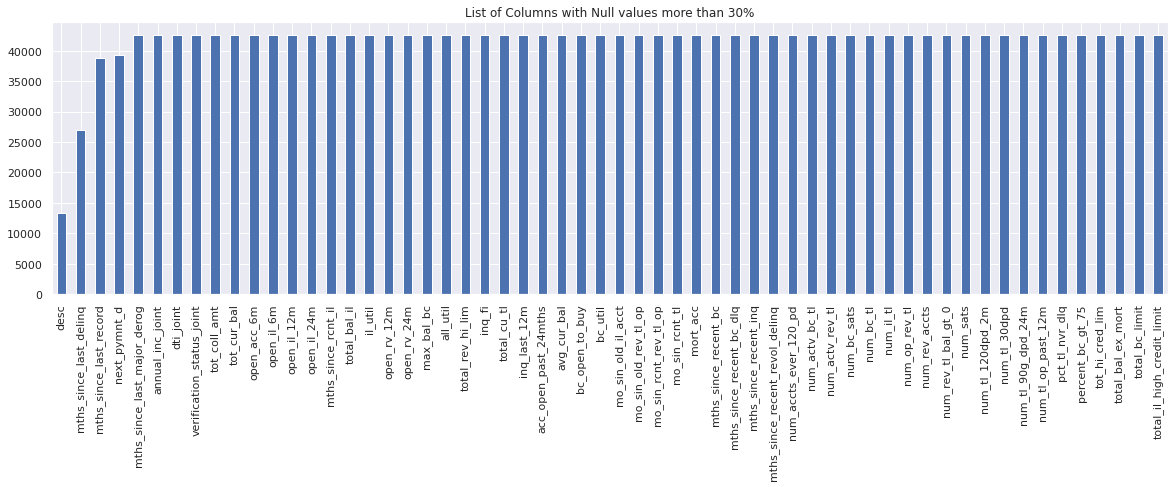

In [ ]:
# Columns with NA more than 30%
NA_col = loan.isnull().sum()
NA_col = NA_col[NA_col.values >(0.3*len(loan))]
print("Number of columns with more than 30% Null values: " + str(NA_col.count()))
plt.figure(figsize=(20,5))
NA_col.plot(kind='bar')
plt.title('List of Columns with Null values more than 30%')
plt.show()

<font color='#0dab7f'><b>Intution</b>: <b>54</b> Columns has all null values and <b>4</b> Columns has more than 30% null values. We will remove columns with more than 30% if null values</font>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2. Data Cleaning

In [11]:
#UDF Name            : removeNull
#Input parameters    : a. dataframe - Dataframe to operate on
#                      b. axis - 0 for row and 1 for column
#                      c. percent - percent of data where column/rows value are null
#Output parameter    : dataframe - dataframe with columns/rows deleted having more than x% of Null values

def removeNull(dataframe, axis = 1, percent = 0.3):
    df = dataframe.copy()
    print("Input dataframe rows,columns",df.shape)

    if axis == 0:
        rownames = df.transpose().isnull().sum()
        rownames = list(rownames[rownames.values > percent*len(df)].index)
        df.drop(df.index[rownames],inplace=True)
        print("Number of Rows dropped: ",len(rownames))
    else:
        colnames = (df.isnull().sum()/len(df))
        colnames = list(colnames[colnames.values>=percent].index)
        df.drop(labels = colnames,axis =1,inplace=True)
        print("Number of Columns dropped: ",len(colnames))

    print("Output dataframe rows,columns",df.shape)

    return df

In [12]:
# Remove columns with more than 30% Null
loan = removeNull(loan, axis = 1 ,percent = 0.3)

Input dataframe rows,columns (42542, 115)
Number of Columns dropped:  58
Output dataframe rows,columns (42542, 57)


In [13]:
# Remove rows with more than 30% Null (0)
loan = removeNull(loan, axis = 0, percent = 0.3)

Input dataframe rows,columns (42542, 57)
Number of Rows dropped:  0
Output dataframe rows,columns (42542, 57)


In [14]:
# Check for each column on how many different values it can have
# Used to find if categorical variables (less than 9) else continous variables.
loan.nunique()

,0
id,42538
member_id,42535
loan_amnt,898
funded_amnt,1051
funded_amnt_inv,9240
term,2
int_rate,394
installment,16459
grade,7
sub_grade,35


In [15]:
# Remove columns where number of unique value is only 1. Since it will not affect analysis
unique = loan.nunique()
unique = unique[unique.values == 1]
print("Old dataset rows,columns",loan.shape )
loan.drop(labels = list(unique.index), axis = 1, inplace = True)
print("New dataset rows,columns",loan.shape )

Old dataset rows,columns (42542, 57)
New dataset rows,columns (42542, 52)


In [16]:
# Percentage of rows having null value for each of columns
print(((loan.isna().sum()/len(loan.index))*100).round())

id                        0.00
member_id                 0.00
loan_amnt                 0.00
funded_amnt               0.00
funded_amnt_inv           0.00
term                      0.00
int_rate                  0.00
installment               0.00
grade                     0.00
sub_grade                 0.00
emp_title                 6.00
emp_length                3.00
home_ownership            0.00
annual_inc                0.00
verification_status       0.00
issue_d                   0.00
loan_status               0.00
pymnt_plan                0.00
url                       0.00
purpose                   0.00
title                     0.00
zip_code                  0.00
addr_state                0.00
dti                       0.00
delinq_2yrs               0.00
earliest_cr_line          0.00
fico_range_low            0.00
fico_range_high           0.00
inq_last_6mths            0.00
open_acc                  0.00
pub_rec                   0.00
revol_bal                 0.00
revol_ut

In [17]:
loan.emp_length.unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [18]:
# Replace emp_length having "nan" with "0"
print(loan.emp_length.unique())
loan.emp_length.fillna('0',inplace=True)
print(loan.emp_length.unique())

# Set the order for experience
emp_length_order = ["0", "< 1 year", "1 year", "2 years", "3 years",  "4 years", "5 years", "6 years", "7 years","8 years", "9 years",  "10+ years"]
loan['emp_length'] = pd.Categorical(loan['emp_length'],categories=emp_length_order, ordered=True)
print(loan.emp_length.unique())

['10+ years' '< 1 year' '1 year' '3 years' '8 years' '9 years' '4 years'
 '5 years' '6 years' '2 years' '7 years' nan]
['10+ years' '< 1 year' '1 year' '3 years' '8 years' '9 years' '4 years'
 '5 years' '6 years' '2 years' '7 years' '0']
['10+ years', '< 1 year', '1 year', '3 years', '8 years', ..., '5 years', '6 years', '2 years', '7 years', '0']
Length: 12
Categories (12, object): ['0' < '< 1 year' < '1 year' < '2 years' ... '7 years' < '8 years' <
                          '9 years' < '10+ years']


/tmp/ipykernel_450/1328269812.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan.emp_length.fillna('0',inplace=True)


In [19]:
# Business Driven - Drop columns not required for Analysis
loan.nunique()

,0
id,42538
member_id,42535
loan_amnt,898
funded_amnt,1051
funded_amnt_inv,9240
term,2
int_rate,394
installment,16459
grade,7
sub_grade,35


In [20]:
print("Before drop rows and columns: ",loan.shape)
not_required_columns = ["id","member_id","url","zip_code"]
loan.drop(labels = not_required_columns, axis = 1, inplace = True)
print("Afore drop rows and columns: ",loan.shape)

Before drop rows and columns:  (42542, 52)
Afore drop rows and columns:  (42542, 48)


In [21]:
# Type cast all continous/numeric variables to numeric
numeric_columns = ['loan_amnt','funded_amnt','funded_amnt_inv','installment','annual_inc','dti']
loan[numeric_columns] = loan[numeric_columns].apply(pd.to_numeric)

In [22]:
# Remove % sign from interest rate
loan['int_rate'] = loan['int_rate'].str.rstrip('%').astype('float')

In [23]:
loan.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,acc_now_delinq,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,"5,000.00","5,000.00","4,975.00",36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,"24,000.00",Verified,Dec-11,Fully Paid,n,credit_card,Computer,AZ,27.65,0,Jan-85,735,739,1,3,0,13648,83.70%,9,0,0,5863.155187,5833.84,5000,863.16,0,0,0,Jan-15,171.62,Sep-16,744,740,0,0,0,0
1,"2,500.00","2,500.00","2,500.00",60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,"30,000.00",Source Verified,Dec-11,Charged Off,n,car,bike,GA,1.00,0,Apr-99,740,744,5,3,0,1687,9.40%,4,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,Apr-13,119.66,Sep-16,499,0,0,0,0,0
2,"2,400.00","2,400.00","2,400.00",36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,"12,252.00",Not Verified,Dec-11,Fully Paid,n,small_business,real estate business,IL,8.72,0,Nov-01,735,739,2,2,0,2956,98.50%,10,0,0,3005.666844,3005.67,2400,605.67,0,0,0,Jun-14,649.91,Sep-16,719,715,0,0,0,0
3,"10,000.00","10,000.00","10,000.00",36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,"49,200.00",Source Verified,Dec-11,Fully Paid,n,other,personel,CA,20.00,0,Feb-96,690,694,1,10,0,5598,21%,37,0,0,12231.89,12231.89,10000,2214.92,16.97,0,0,Jan-15,357.48,Apr-16,604,600,0,0,0,0
4,"3,000.00","3,000.00","3,000.00",60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,"80,000.00",Source Verified,Dec-11,Current,n,other,Personal,OR,17.94,0,Jan-96,695,699,0,15,0,27783,53.90%,38,270.78,270.78,3784.49,3784.49,2729.22,1055.27,0,0,0,Sep-16,67.79,Sep-16,694,690,0,0,0,0


In [24]:
# Check different categories for purpose
(loan.purpose.value_counts()*100)/len(loan)

,count
purpose,
debt_consolidation,46.49
credit_card,12.87
other,10.40
home_improvement,7.52
major_purchase,5.43
small_business,4.68
car,3.80
wedding,2.36
medical,1.77


In [25]:
# Drop loan with purpose as "other" or less than 0.75%
print("Before drop rows and columns: ",loan.shape)
del_loan_purpose = (loan.purpose.value_counts()*100)/len(loan)
del_loan_purpose = del_loan_purpose[(del_loan_purpose < 0.75) | (del_loan_purpose.index == 'other')]

loan.drop(labels = loan[loan.purpose.isin(del_loan_purpose.index)].index, inplace=True)
print("After drop rows and columns: ",loan.shape)

print(loan.purpose.unique())

Before drop rows and columns:  (42542, 48)
After drop rows and columns:  (38011, 48)
['credit_card' 'car' 'small_business' 'wedding' 'debt_consolidation'
 'home_improvement' 'major_purchase' 'medical' 'moving' 'vacation' 'house'
 'educational' nan]


In [26]:
# Check different categories for loan_status
(loan.loan_status.value_counts()*100)/len(loan)

,count
loan_status,
Fully Paid,79.45
Charged Off,13.15
Does not meet the credit policy. Status:Fully Paid,4.43
Does not meet the credit policy. Status:Charged Off,1.68
Current,1.19
In Grace Period,0.04
Late (31-120 days),0.03
Late (16-30 days),0.01
Default,0.00


## Step 3:  Derived Metrics
1. Type Driven
2. Business Driven
3. Data Driven

In [27]:
# Business Driven -  Loan amount to Annual Income ratio
loan['loan_income_ratio']= loan['loan_amnt'] / loan['annual_inc']

In [30]:
# Type Driven - Extract Year & Month from Issue date
loan['issue_month'] = loan['issue_d'].str.split('-', expand=True)[0]
loan['issue_year'] = loan['issue_d'].str.split('-', expand=True)[1]
loan[['issue_d','issue_month','issue_year']].head()

,issue_d,issue_month,issue_year
0,Dec-11,Dec,11
1,Dec-11,Dec,11
2,Dec-11,Dec,11
5,Dec-11,Dec,11
6,Dec-11,Dec,11


In [31]:
# Type Driven
# Set the order - months from Jan to Dec
months_order = ["Jan", "Feb", "Mar", "Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
loan['issue_month'] = pd.Categorical(loan['issue_month'],categories=months_order, ordered=True)

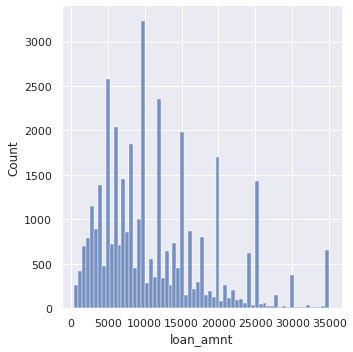

In [ ]:
# To decide on Bin Range in next step
sns.displot(loan['loan_amnt'])
plt.show()

In [32]:
# Type Driven - Create Bins (Categorical Vriable) for range of Loan Amount
bins = [0, 5000, 10000, 15000, 20000, 25000,40000]
slot = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-25000','25000 and above']
loan['loan_amnt_range'] = pd.cut(loan['loan_amnt'], bins, labels=slot)
loan['loan_amnt_range']

,loan_amnt_range
0,0-5000
1,0-5000
2,0-5000
5,0-5000
6,5000-10000
...,...
42516,0-5000
42538,NaN
42539,NaN
42540,NaN


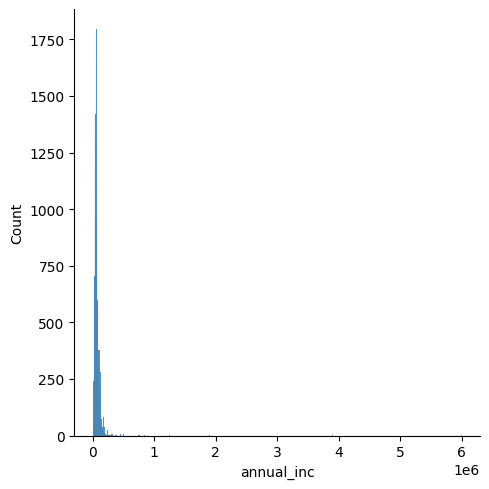

In [33]:
# To decide on Bin Range in next step
sns.displot(loan['annual_inc'])
plt.show()

# Note: 1e6 Shows high distribution of salary

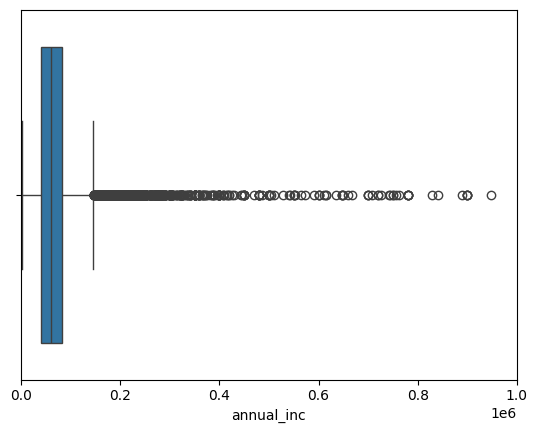

In [34]:
# To decide on Bin Range in next step
sns.boxplot(data =loan, x='annual_inc')
plt.xlim(-100, 1000000)
plt.show()

In [35]:
# Type Driven - Create Bins (Categorical Vriable) for range of Annual Income
bins = [0, 25000, 50000, 75000, 100000,1000000]
slot = ['0-25000', '25000-50000', '50000-75000', '75000-100000', '100000 and above']
loan['annual_inc_range'] = pd.cut(loan['annual_inc'], bins, labels=slot)
loan[['annual_inc_range', 'annual_inc']]

,annual_inc_range,annual_inc
0,0-25000,"24,000.00"
1,25000-50000,"30,000.00"
2,0-25000,"12,252.00"
5,25000-50000,"36,000.00"
6,25000-50000,"47,004.00"
...,...,...
42516,25000-50000,"30,000.00"
42538,NaN,NaN
42539,NaN,NaN
42540,NaN,NaN


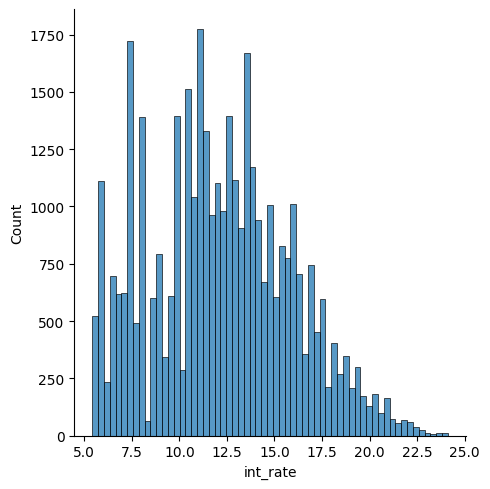

In [36]:
# To decide on Bin Range in next step
sns.displot(loan['int_rate'])
plt.show()

In [37]:
# Type Driven - Create Bins (Categorical Vriable) for range of Interest rate
bins = [0, 7.5, 10, 12.5, 15,20]
slot = ['0-7.5', '7.5-10', '10-12.5', '12.5-15', '15 and above']
loan['int_rate_range'] = pd.cut(loan['int_rate'], bins, labels=slot)

<a id='univariate'></a>

## Step 4: Univariate Analysis

In [38]:
#UDF Name            : univariateAnalysis
#Input parameters    : a. dataframe - Dataframe to operate on
#                      b. col - Column for which Univariate analysis is required to be done
#                      c. variable - 0 for Continous and 1 for Categorical
#                      d. hue - plot against what for categorical variable
#Output parameter    : Nil
# Description        : For variable = 0, continous variable, plot - Distribution Plot, Violin Plot and Box Plot
#                      For variable = 1, Categorical variable, plot - Count Plot

def univariateAnalysis(df, col, vartype, hue = None):
    sns.set(style="darkgrid")

    if vartype == 0:
        fig, ax=plt.subplots(nrows =1,ncols=3,figsize=(20,8))
        ax[0].set_title("Distribution Plot")
        sns.histplot(df[col],ax=ax[0], kde=True)
        ax[1].set_title("Violin Plot")
        sns.violinplot(data =df, x=col,ax=ax[1], inner="quartile")
        ax[2].set_title("Box Plot")
        sns.boxplot(data =df, x=col,ax=ax[2])

    if vartype == 1:
        temp = pd.Series(data = hue,dtype=pd.StringDtype())
        fig, ax = plt.subplots()
        width = len(df[col].unique()) + 6 + 4*len(temp.unique())
        fig.set_size_inches(width , 7)
        ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue)
        plt.xticks(rotation=90)
        plt.legend(loc='upper right')
        del temp
    else:
        exit

    plt.show()

### Step 4.1: Continuous Variables

In [39]:
loan.describe(percentiles=[0.05,0.1,0.25,0.30,0.50,0.60,0.75,0.80,0.90,0.95,0.99])

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,loan_income_ratio
count,"38,004.00","38,004.00","38,004.00","38,004.00","38,004.00","38,004.00","38,004.00","38,004.00"
mean,"11,463.40","11,183.98","10,497.00",12.19,333.03,"69,700.20",13.49,0.19
std,"7,440.00","7,173.51","7,171.24",3.72,209.68,"64,854.89",6.69,0.12
min,500.00,500.00,0.00,5.42,15.67,"1,896.00",0.00,0.00
5%,"2,500.00","2,500.00","1,750.00",6.39,77.76,"24,000.00",2.26,0.04
10%,"3,500.00","3,500.00","2,850.00",7.19,105.56,"30,000.00",4.26,0.06
25%,"6,000.00","5,775.00","5,000.00",9.63,173.24,"41,143.20",8.38,0.10
30%,"6,300.00","6,125.00","5,916.19",10.25,194.65,"45,000.00",9.49,0.11
50%,"10,000.00","10,000.00","9,000.00",11.99,291.38,"60,000.00",13.57,0.17
60%,"12,000.00","12,000.00","10,600.00",13.11,338.93,"66,600.00",15.55,0.20


#### 4.1.1: Loan Amount

In [40]:
loan.loan_amnt.describe()

,loan_amnt
count,"38,004.00"
mean,"11,463.40"
std,"7,440.00"
min,500.00
25%,"6,000.00"
50%,"10,000.00"
75%,"15,000.00"
max,"35,000.00"


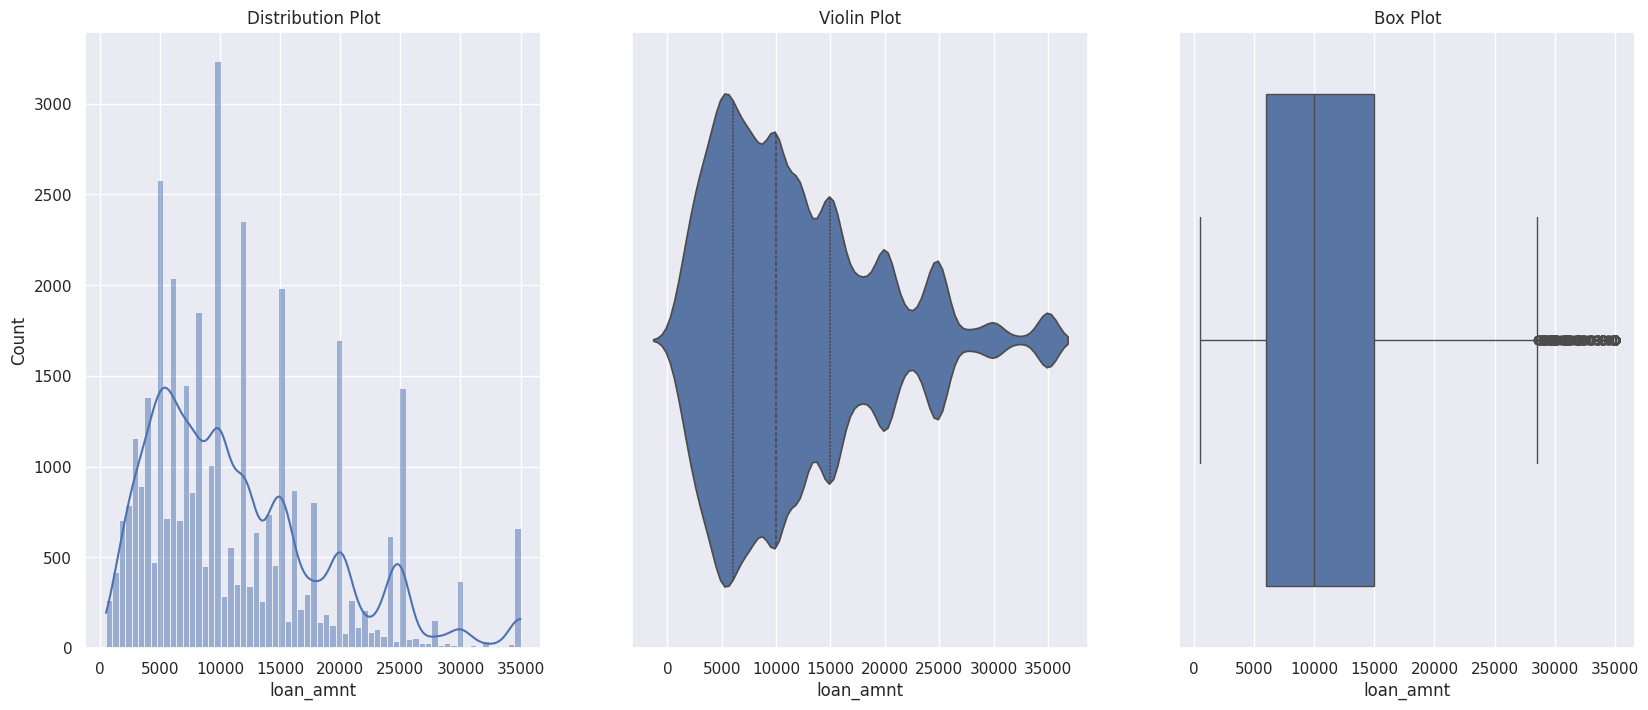

In [41]:
univariateAnalysis(loan,'loan_amnt',0)

<font color='#0dab7f'><b>Intution</b>: Most Loan amounts are between <b>6000 to 15000 USD.</b></font>

#### 4.1.2. Interest Rate

In [42]:
loan.int_rate.describe()

,int_rate
count,"38,004.00"
mean,12.19
std,3.72
min,5.42
25%,9.63
50%,11.99
75%,14.79
max,24.11


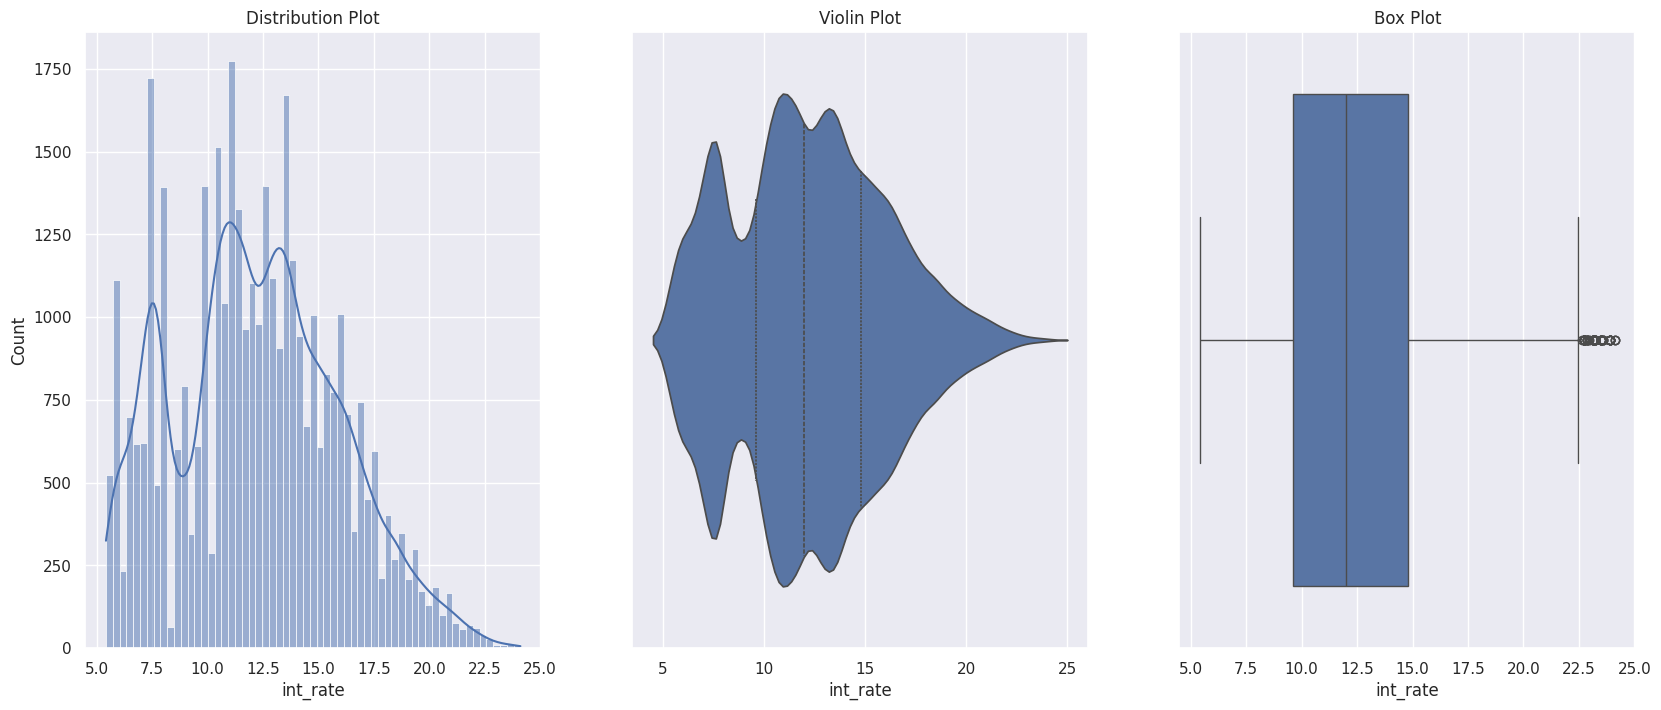

In [43]:
univariateAnalysis(loan,'int_rate',0)

<font color='#0dab7f'><b>Intution</b>: Most of Loan Interest rates are between <b>9.25% and 14.61%.</b></font>

#### 4.1.3. Annual Income

In [44]:
loan["annual_inc"].describe()

,annual_inc
count,"38,004.00"
mean,"69,700.20"
std,"64,854.89"
min,"1,896.00"
25%,"41,143.20"
50%,"60,000.00"
75%,"83,200.00"
max,"6,000,000.00"


In [45]:
# Since we see outlier, we need to remove it. Lets see which percentile to remove
loan["annual_inc"].describe(percentiles=[0.05,0.1,0.25,0.30,0.50,0.60,0.75,0.80,0.90,0.95,0.99])

,annual_inc
count,"38,004.00"
mean,"69,700.20"
std,"64,854.89"
min,"1,896.00"
5%,"24,000.00"
10%,"30,000.00"
25%,"41,143.20"
30%,"45,000.00"
50%,"60,000.00"
60%,"66,600.00"


In [46]:
# Outlier is after 99 percentile. 6,000,000 which is approx 86 times more than mean value
# Remove from 99 percentile onwards
q = loan["annual_inc"].quantile(0.99)
loan = loan[loan["annual_inc"] <= q]
loan["annual_inc"].describe()

,annual_inc
count,"37,623.00"
mean,"66,175.29"
std,"35,674.14"
min,"1,896.00"
25%,"41,000.00"
50%,"59,484.00"
75%,"82,000.00"
max,"240,734.00"


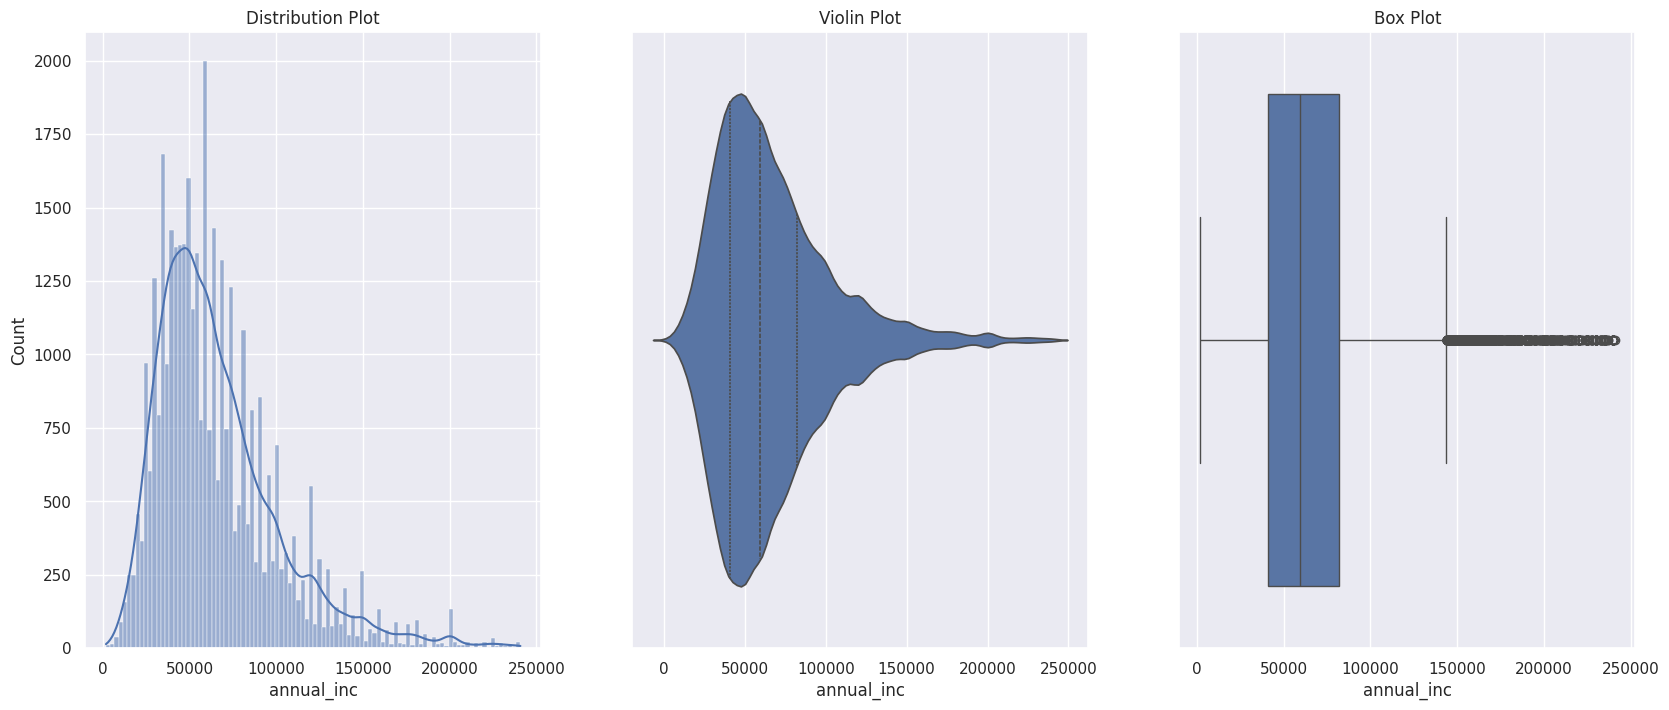

In [47]:
univariateAnalysis(df=loan,col='annual_inc',vartype=0)

<font color='#0dab7f'><b>Intution</b>: Most of Applicants earn between <b>41000 to 82000 USD annually.</b></font>

### Step 4.2: Categorical Variables

#### 4.2.1 Loan Status

,loan_amnt
loan_status,
Charged Off,0.13
Current,0.01
Default,0.00
Does not meet the credit policy. Status:Charged Off,0.02
Does not meet the credit policy. Status:Fully Paid,0.04
Fully Paid,0.79
In Grace Period,0.00
Late (16-30 days),0.00
Late (31-120 days),0.00


/tmp/ipykernel_450/1422502960.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


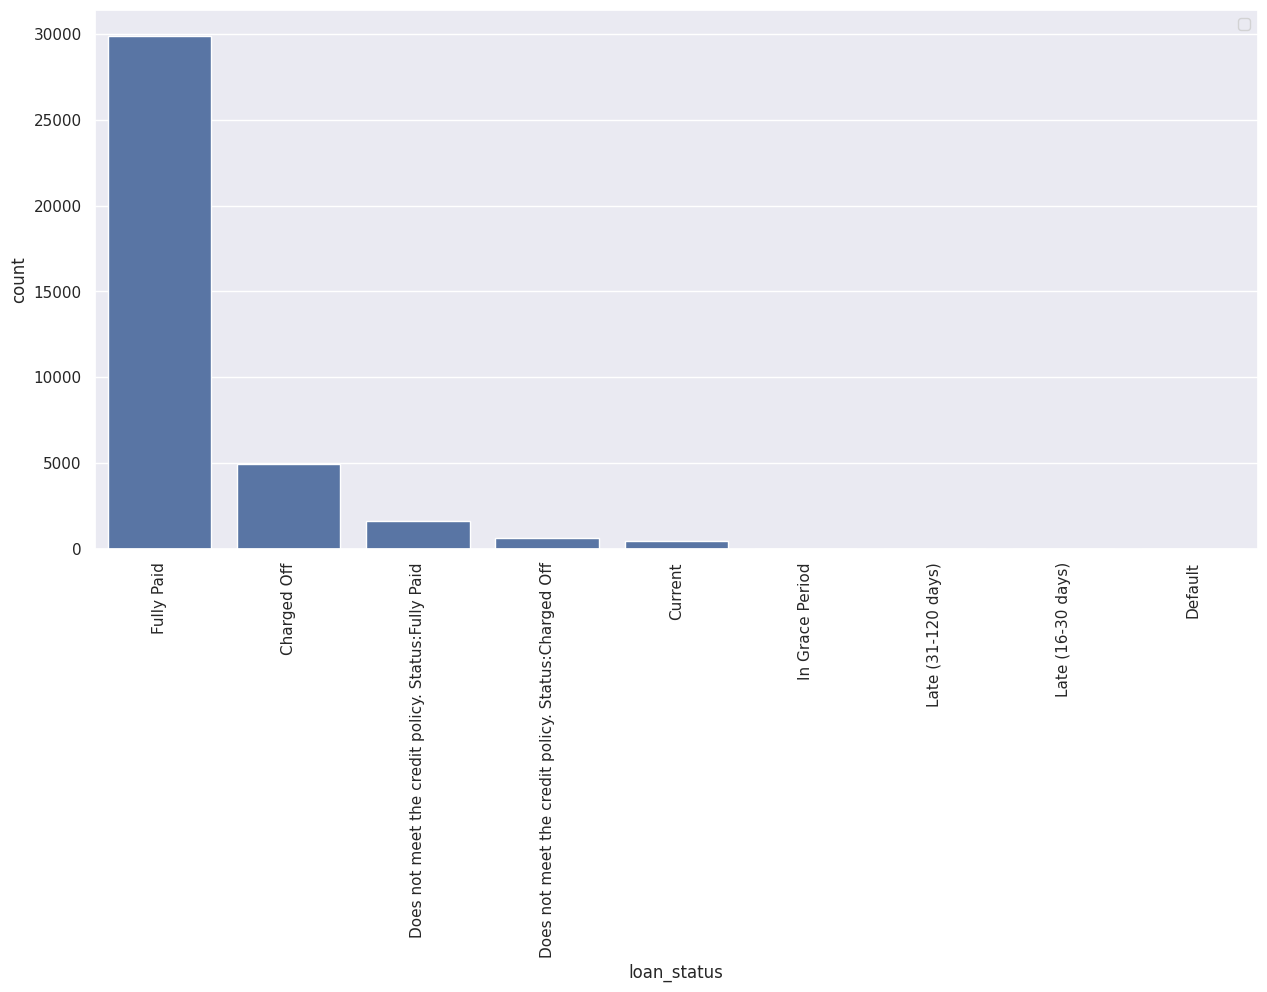

In [48]:
display(loan.groupby('loan_status').count().loan_amnt/len(loan.loan_status))
univariateAnalysis(df=loan,col='loan_status',vartype=1)

<font color='#0dab7f'><b>Intution</b>: <b>13%</b> of the applicants <b>Charged off</b>.</font>

#### 4.2.2. Purpose of loan

,loan_amnt
purpose,
car,0.04
credit_card,0.14
debt_consolidation,0.52
educational,0.01
home_improvement,0.08
house,0.01
major_purchase,0.06
medical,0.02
moving,0.02


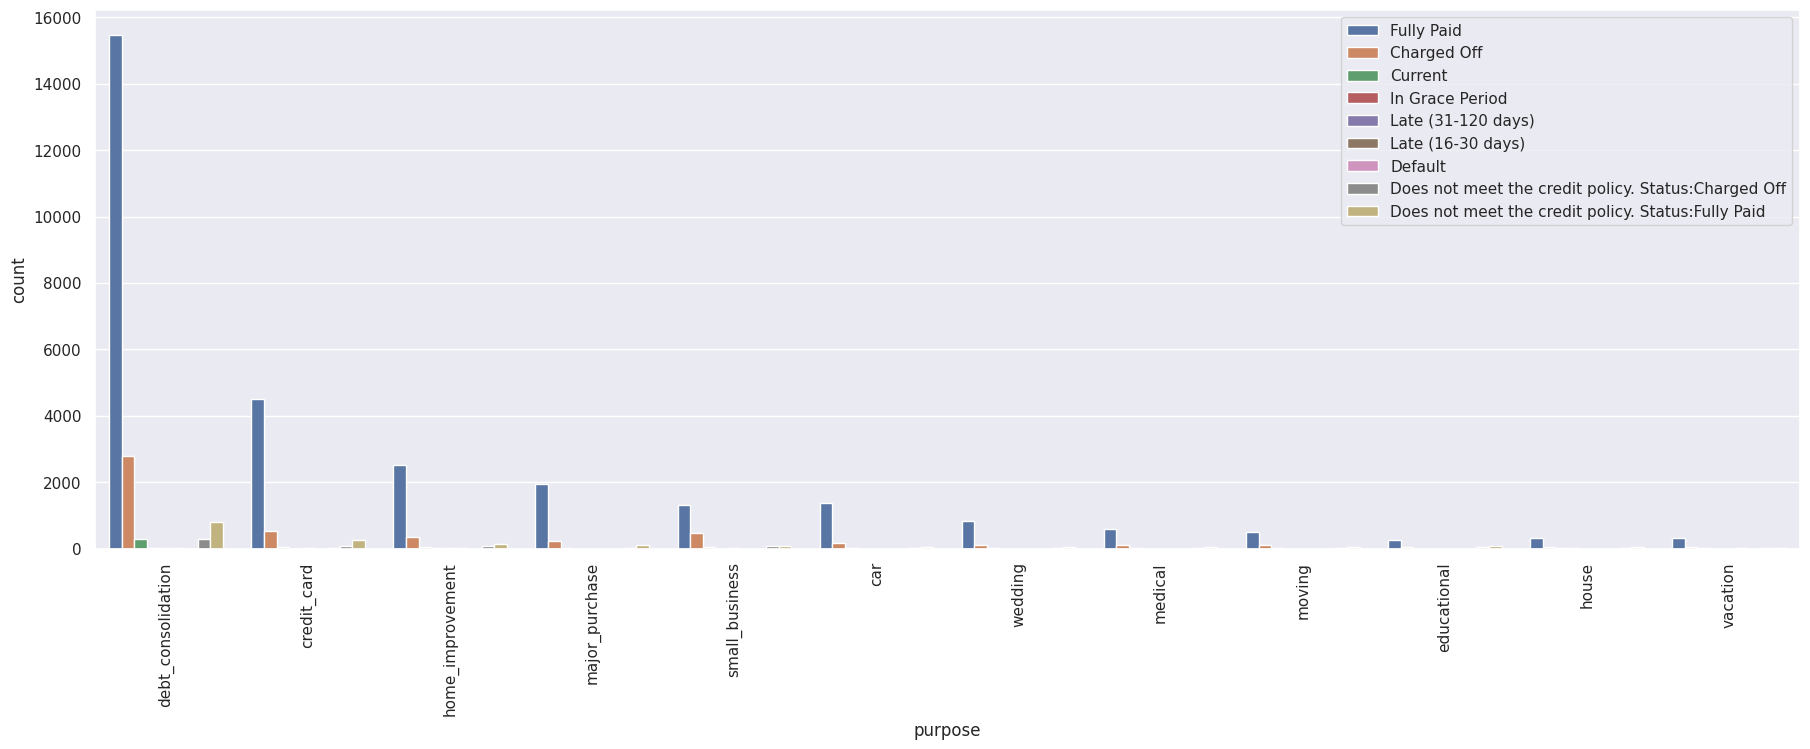

In [49]:
display(loan.groupby('purpose').count().loan_amnt/len(loan.purpose))
univariateAnalysis(df=loan,col='purpose',vartype=1,hue='loan_status')

<font color='#0dab7f'><b>Intution</b>:  Approx <b>52%</b> of the applicants applied loan for paying their other loans<b>(Debt Consolidation)

Small Business</b> Looks more <b>risky</b>.</font>

#### 4.2.3. Home Ownership wise Loan

In [50]:
loan.home_ownership.unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'NONE'], dtype=object)

In [51]:
# Remove rows where home_ownership'=='OTHER', 'NONE', 'ANY'
rem = ['OTHER', 'NONE', 'ANY']
loan.drop(loan[loan['home_ownership'].isin(rem)].index,inplace=True)
loan.home_ownership.unique()

/tmp/ipykernel_450/1365069987.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan.drop(loan[loan['home_ownership'].isin(rem)].index,inplace=True)


array(['RENT', 'OWN', 'MORTGAGE'], dtype=object)

,loan_amnt
home_ownership,
MORTGAGE,0.45
OWN,0.07
RENT,0.47


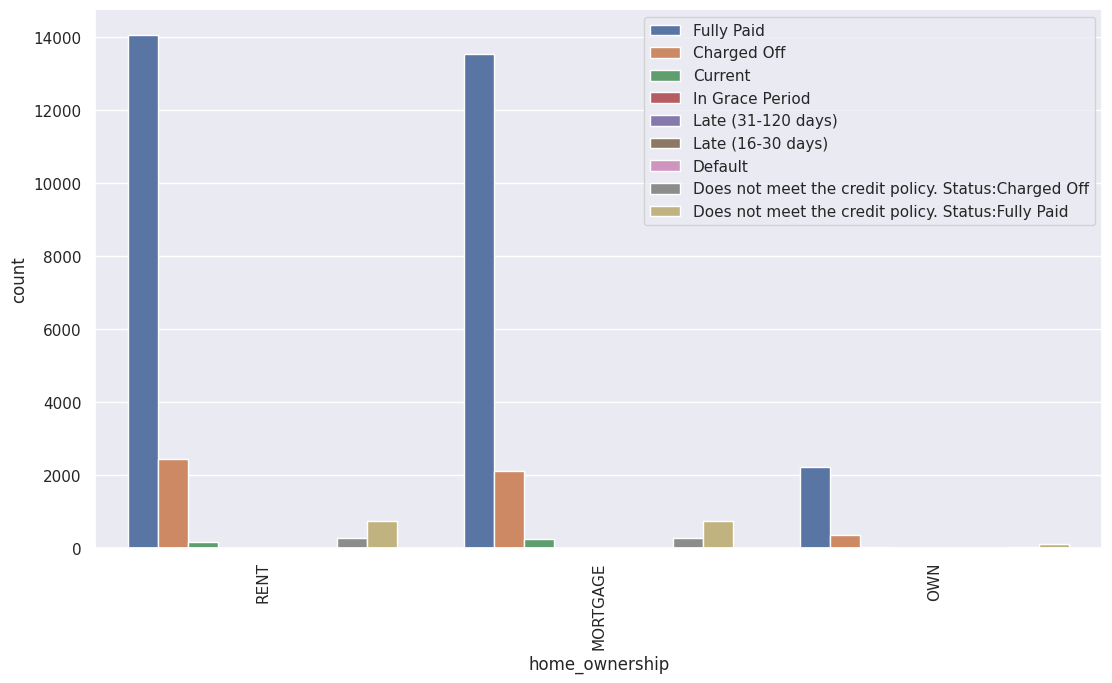

In [52]:
display(loan.groupby('home_ownership').count().loan_amnt/len(loan.home_ownership))
univariateAnalysis(df=loan,col='home_ownership',vartype=1,hue='loan_status')

<font color='#0dab7f'><b>Intution</b>: <b>47%</b> of applicants are living in <b>rented home</b> whereas <b>45% </b>applicants were <b>mortagaged</b> their home.</font>

#### 4.2.4. Year wise Loan

,loan_amnt
issue_year,
07,0.01
08,0.05
09,0.12
10,0.29
11,0.52


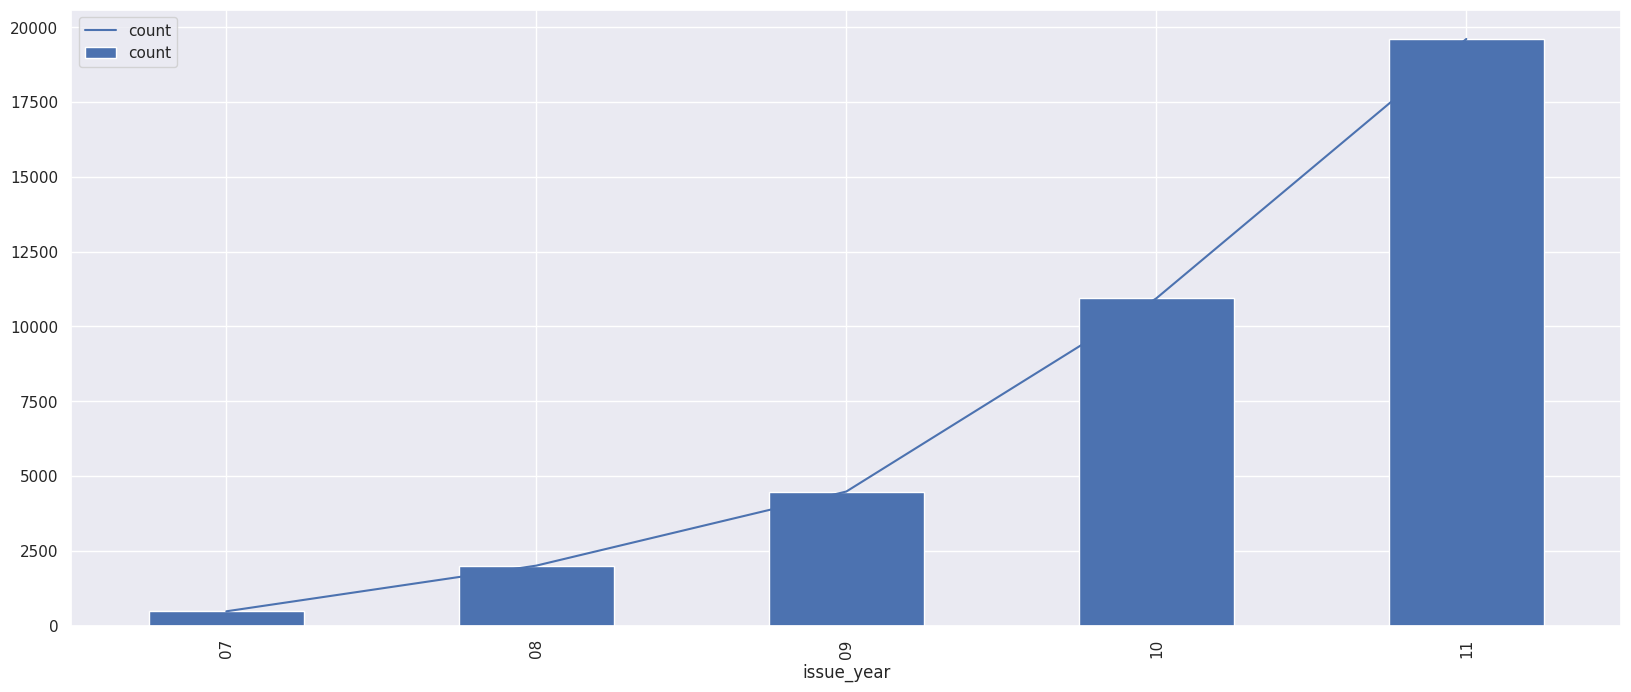

In [53]:
display(loan.groupby('issue_year').count().loan_amnt/len(loan.issue_year))

year_wise =loan.groupby(by= [loan.issue_year])[['loan_status']].count()
year_wise.rename(columns={"loan_status": "count"},inplace=True)
ax =year_wise.plot(figsize=(20,8))
year_wise.plot(kind='bar',figsize=(20,8),ax = ax)
plt.show()

<font color='#0dab7f'><b>Intution</b>: loan applicants are increasing year on year, approx <b>56%</b> of loan applicants received loans in <b>2011</b></font>

#### 4.2.5. Loan Term

,loan_amnt
term,
36 months,0.73
60 months,0.27


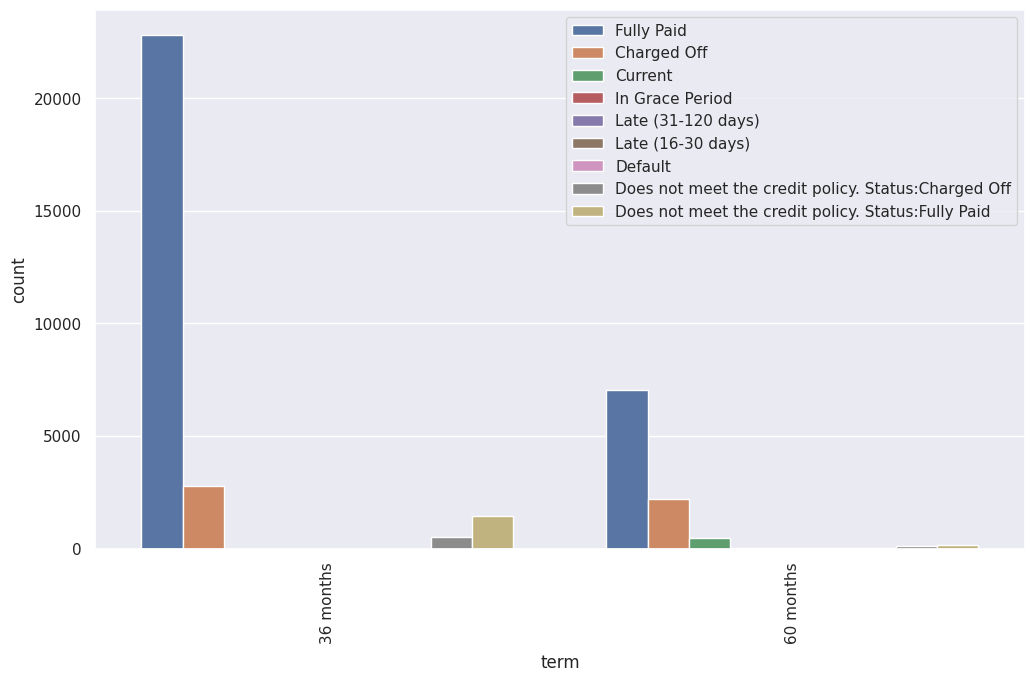

In [54]:
display(loan.groupby('term').count().loan_amnt/len(loan.term))
univariateAnalysis(df=loan,col='term',vartype=1,hue='loan_status')

<font color='#0dab7f'><b>Intution</b>: <b>73%</b> of applicants applied loan for <b>36 months</b> term period.</font>

In [55]:
loan.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,acc_now_delinq,delinq_amnt,pub_rec_bankruptcies,tax_liens,loan_income_ratio,issue_month,issue_year,loan_amnt_range,annual_inc_range,int_rate_range
0,"5,000.00","5,000.00","4,975.00",36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,"24,000.00",Verified,Dec-11,Fully Paid,n,credit_card,Computer,AZ,27.65,0,Jan-85,735,739,1,3,0,13648,83.70%,9,0,0,5863.155187,5833.84,5000,863.16,0,0,0,Jan-15,171.62,Sep-16,744,740,0,0,0,0,0.21,Dec,11,0-5000,0-25000,10-12.5
1,"2,500.00","2,500.00","2,500.00",60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,"30,000.00",Source Verified,Dec-11,Charged Off,n,car,bike,GA,1.00,0,Apr-99,740,744,5,3,0,1687,9.40%,4,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,Apr-13,119.66,Sep-16,499,0,0,0,0,0,0.08,Dec,11,0-5000,25000-50000,15 and above
2,"2,400.00","2,400.00","2,400.00",36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,"12,252.00",Not Verified,Dec-11,Fully Paid,n,small_business,real estate business,IL,8.72,0,Nov-01,735,739,2,2,0,2956,98.50%,10,0,0,3005.666844,3005.67,2400,605.67,0,0,0,Jun-14,649.91,Sep-16,719,715,0,0,0,0,0.20,Dec,11,0-5000,0-25000,15 and above
5,"5,000.00","5,000.00","5,000.00",36 months,7.90,156.46,A,A4,Veolia Transportaton,3 years,RENT,"36,000.00",Source Verified,Dec-11,Fully Paid,n,wedding,My wedding loan I promise to pay back,AZ,11.20,0,Nov-04,730,734,3,9,0,7963,28.30%,12,0,0,5632.21,5632.21,5000,632.21,0,0,0,Jan-15,161.03,Jan-16,679,675,0,0,0,0,0.14,Dec,11,0-5000,25000-50000,7.5-10
6,"7,000.00","7,000.00","7,000.00",60 months,15.96,170.08,C,C5,Southern Star Photography,8 years,RENT,"47,004.00",Not Verified,Dec-11,Fully Paid,n,debt_consolidation,Loan,NC,23.51,0,Jul-05,690,694,1,7,0,17726,85.60%,11,0,0,10137.84001,10137.84,7000,3137.84,0,0,0,May-16,1313.76,Sep-16,654,650,0,0,0,0,0.15,Dec,11,5000-10000,25000-50000,15 and above


## Step 5. Bivariate/Multivariate Analysis

#### 5.1. Purpose of Loan vs Loan Amount for each Loan Status

In [56]:
loancopy = loan.copy()
loancopy = loancopy[(loancopy.loan_status == 'Fully Paid' ) | (loancopy.loan_status == 'Charged Off')]

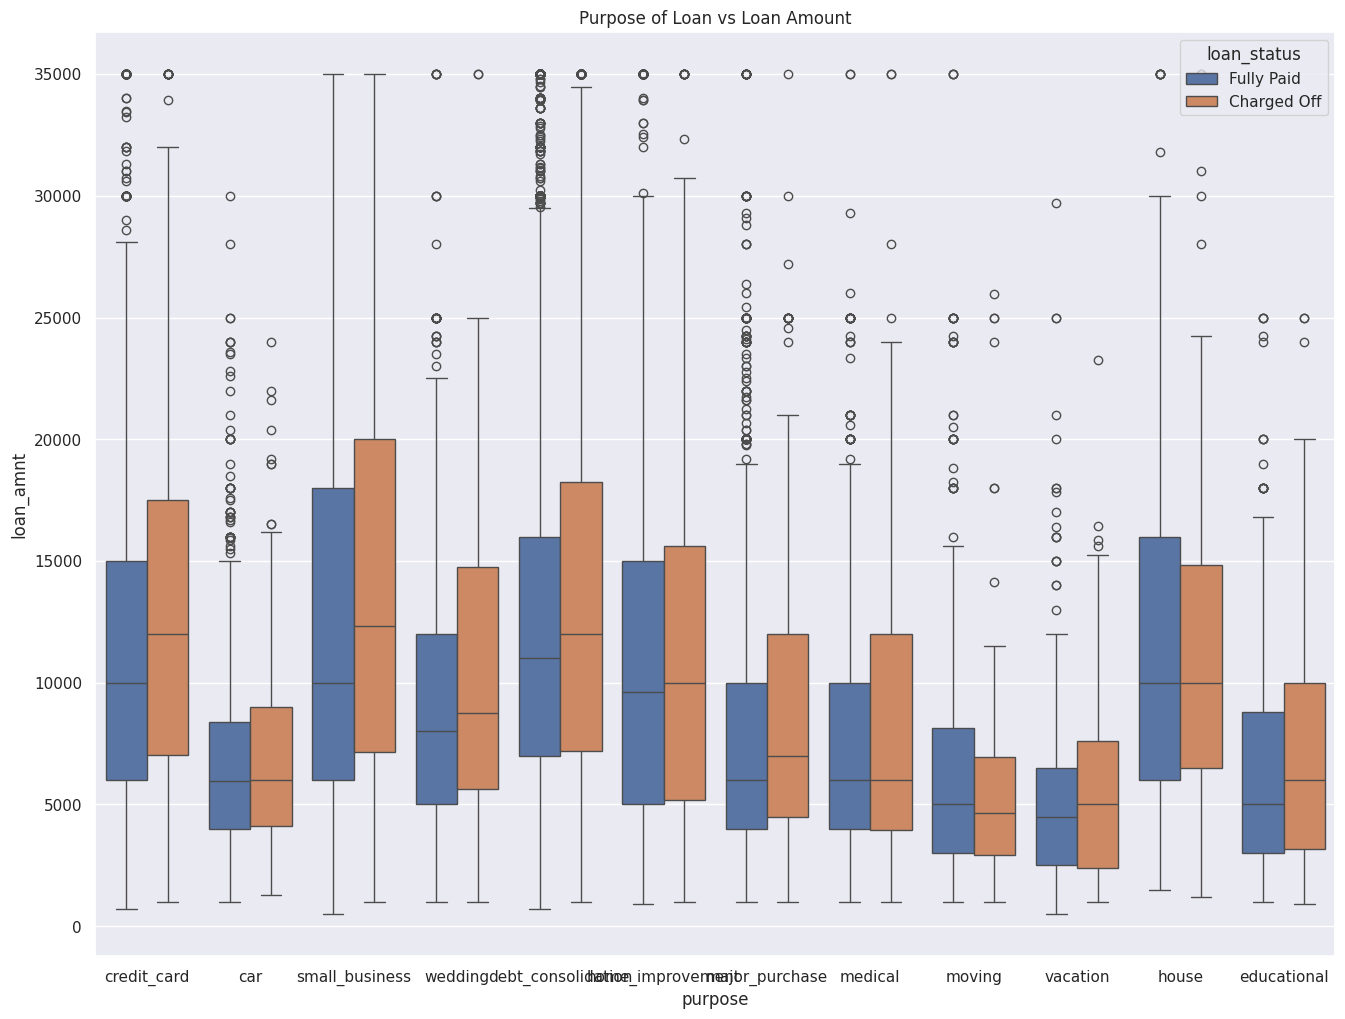

In [57]:
plt.figure(figsize=(16,12))
sns.boxplot(data =loancopy, x='purpose', y='loan_amnt', hue ='loan_status')
plt.title('Purpose of Loan vs Loan Amount')
plt.show()

#### 5.2. Correlation Matrix : All Continuos(Numeric) Variables

In [58]:
loan_correlation = loan.corr()
loan_correlation

ValueError: could not convert string to float: ' 36 months'

#### 5.3. HeatMap: All continuos variables

NameError: name 'loan_correlation' is not defined

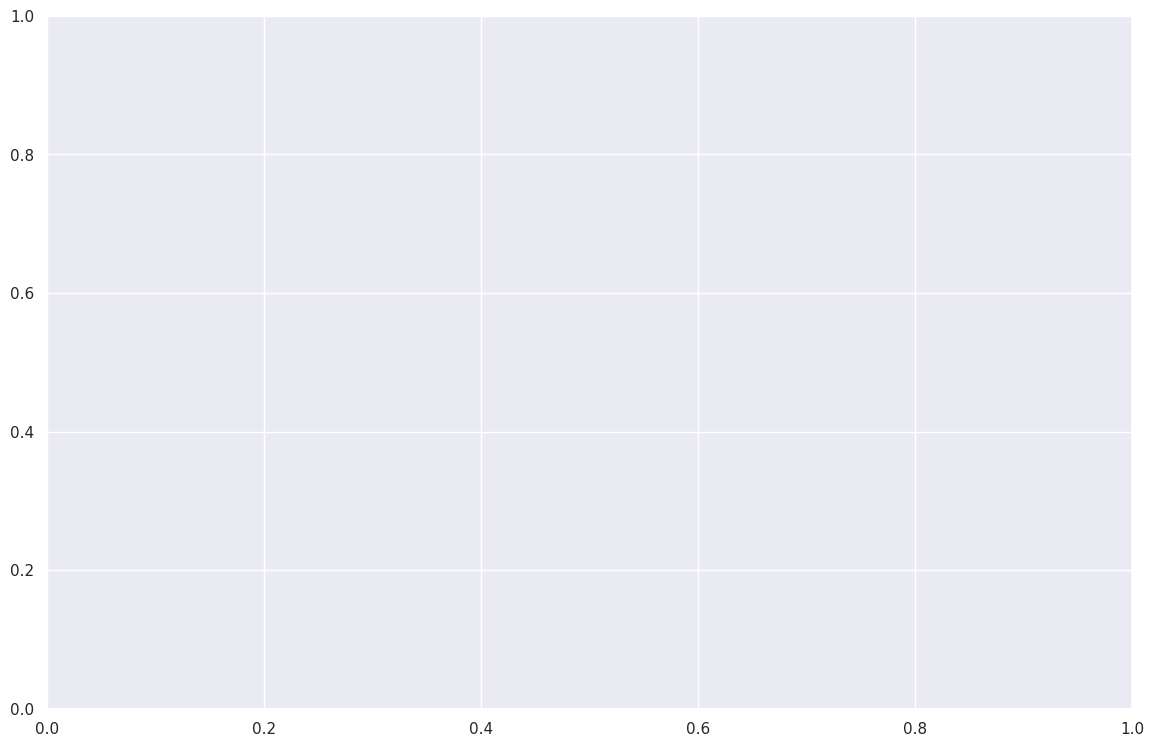

In [59]:
f, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(loan_correlation,
            xticklabels=loan_correlation.columns.values,
            yticklabels=loan_correlation.columns.values,annot= True)
plt.show()

<font color='#0dab7f'><b>Intution</b>: <b>'loan_amnt','funded_amnt' and 'funded_amnt_inv'</b> are <b>closely interrelated</b>. Analyse only loan_amnt and ignore 'funded_amnt' and 'funded_amnt_inv'</font>

#### 5.4. Employment Length vs Loan Amount for each Loan Purpose

In [60]:
loanstatus=loan.pivot_table(index=['loan_status','purpose','emp_length'],values='loan_amnt',aggfunc=('count')).reset_index()
loanstatus=loan.loc[loan['loan_status']=='Charged Off']
loanstatus.head()

/tmp/ipykernel_450/561281400.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  loanstatus=loan.pivot_table(index=['loan_status','purpose','emp_length'],values='loan_amnt',aggfunc=('count')).reset_index()


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,acc_now_delinq,delinq_amnt,pub_rec_bankruptcies,tax_liens,loan_income_ratio,issue_month,issue_year,loan_amnt_range,annual_inc_range,int_rate_range
1,"2,500.00","2,500.00","2,500.00",60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,"30,000.00",Source Verified,Dec-11,Charged Off,n,car,bike,GA,1.00,0,Apr-99,740,744,5,3,0,1687,9.40%,4,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,Apr-13,119.66,Sep-16,499,0,0,0,0,0,0.08,Dec,11,0-5000,25000-50000,15 and above
8,"5,600.00","5,600.00","5,600.00",60 months,21.28,152.39,F,F2,NaN,4 years,OWN,"40,000.00",Source Verified,Dec-11,Charged Off,n,small_business,Expand Business & Buy Debt Portfolio,CA,5.55,0,Apr-04,675,679,2,11,0,5210,32.60%,13,0,0,646.02,646.02,162.02,294.94,0,189.06,2.09,Apr-12,152.39,Sep-16,499,0,0,0,0,0,0.14,Dec,11,5000-10000,25000-50000,NaN
12,"9,000.00","9,000.00","9,000.00",36 months,13.49,305.38,C,C1,Va. Dept of Conservation/Recreation,< 1 year,RENT,"30,000.00",Source Verified,Dec-11,Charged Off,n,debt_consolidation,freedom,VA,10.08,0,Apr-04,710,714,1,4,0,10452,91.70%,9,0,0,2270.7,2270.7,1256.14,570.26,0,444.3,4.16,Jul-12,305.38,Sep-16,619,615,0,0,0,0,0.30,Dec,11,5000-10000,25000-50000,12.5-15
21,"21,000.00","21,000.00","21,000.00",36 months,12.42,701.73,B,B4,Osram Sylvania,10+ years,RENT,"105,000.00",Verified,Dec-11,Charged Off,n,debt_consolidation,Debt Cleanup,FL,13.22,0,Feb-83,705,709,0,7,0,32135,90.30%,38,0,0,14025.4,14025.4,10694.96,3330.44,0,0,0,Sep-13,701.73,Sep-16,534,530,0,0,0,0,0.20,Dec,11,20000-25000,100000 and above,10-12.5
24,"6,000.00","6,000.00","6,000.00",36 months,11.71,198.46,B,B3,bmg-educational,1 year,RENT,"76,000.00",Not Verified,Dec-11,Charged Off,n,major_purchase,cash,CA,2.40,0,Jun-01,690,694,1,7,0,5963,29.70%,7,0,0,2050.14,2050.14,1305.58,475.25,0,269.31,2.57,Oct-12,198.46,Sep-16,499,0,0,0,0,0,0.08,Dec,11,5000-10000,75000-100000,10-12.5


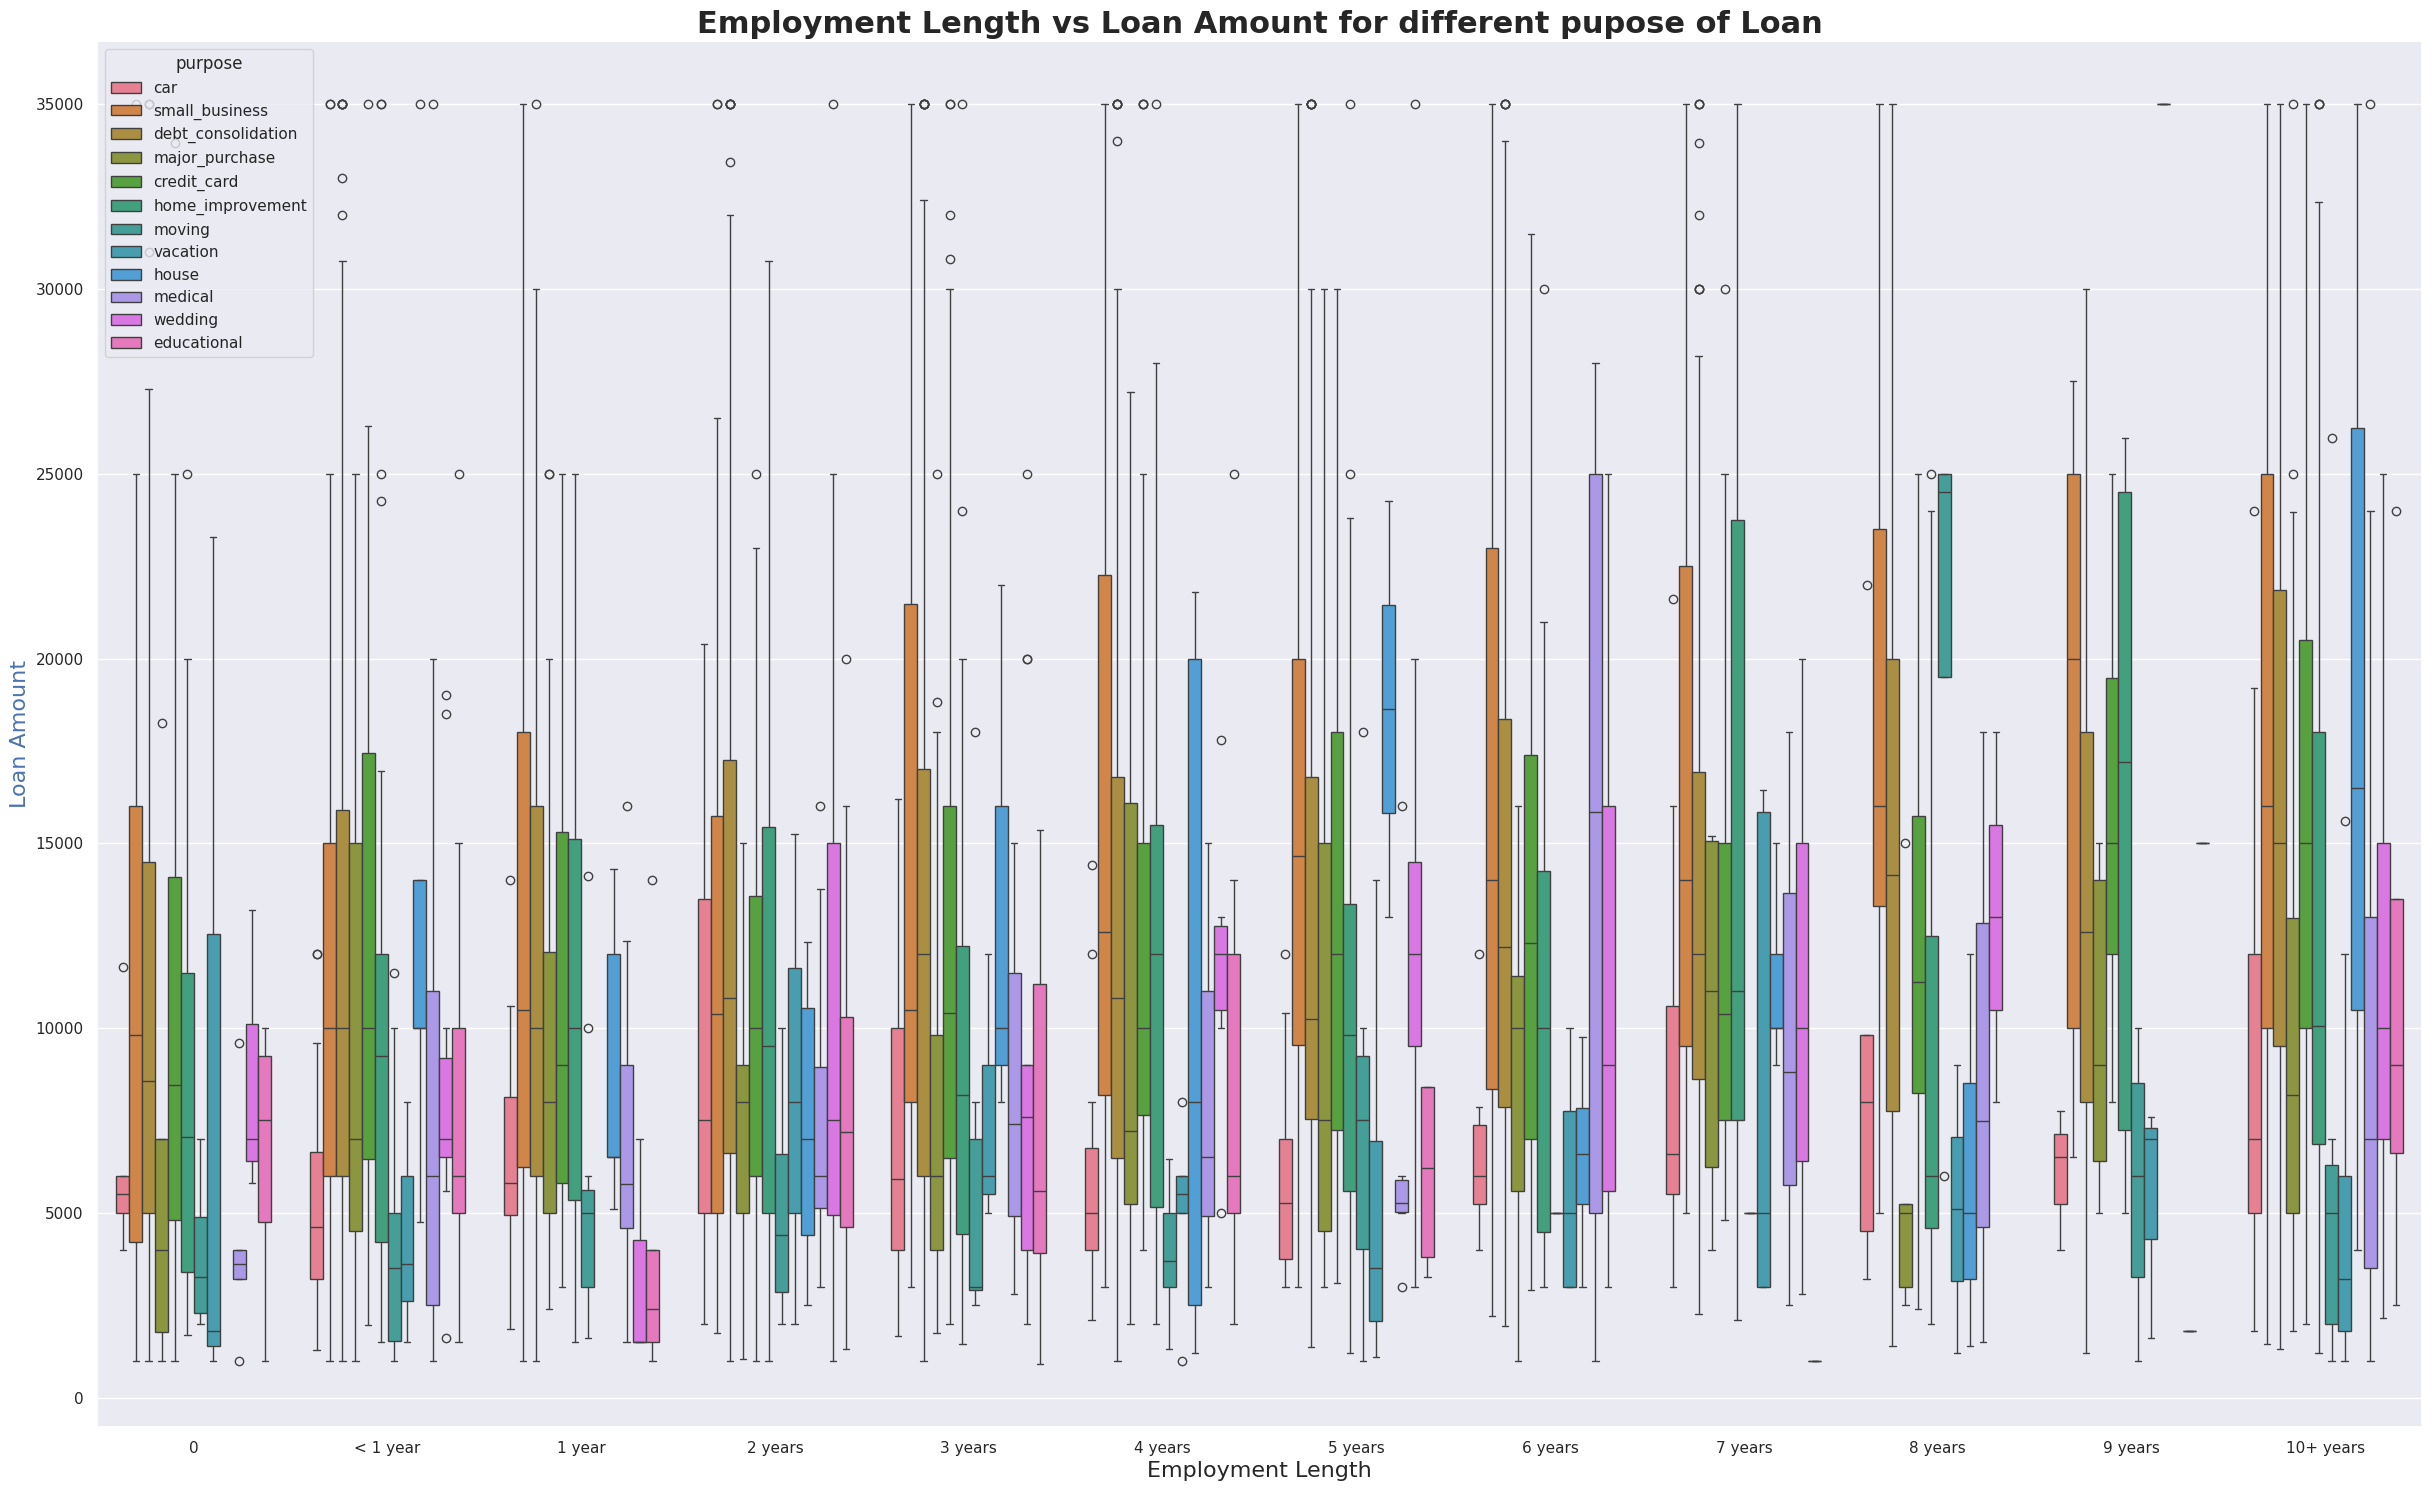

In [61]:
ax = plt.figure(figsize=(30, 18))
ax = sns.boxplot(x='emp_length',y='loan_amnt',hue='purpose',data=loanstatus)
ax.set_title('Employment Length vs Loan Amount for different pupose of Loan',fontsize=22,weight="bold")
ax.set_xlabel('Employment Length',fontsize=16)
ax.set_ylabel('Loan Amount',color = 'b',fontsize=16)
plt.show()

<a id='bivariate_prob'></a>

## Step 6: Bivariate/Multivariate Analysis for Probability of Charge off
We will calculate probability of Charged Off with respect to Fully Paid.
We will ignore all current ongoing loans as outcome of current loan is not known

In [62]:
#UDF Name            : crosstab
#Input parameters    : a. dataframe - Dataframe to operate on
#                      b. col - Column for which cross tab to be taken
#Output parameter    : crosstab - dataframe after taking cross tab
# Description        : It will return crosstab for given dataframe and column

def crosstab(dataframe,col):
    crosstab = pd.crosstab(dataframe[col], dataframe['loan_status'],margins=True)
    crosstab['Probability_Charged Off'] = round((crosstab['Charged Off']/(crosstab['Charged Off'] + crosstab['Fully Paid'])),2)
    return crosstab

In [63]:
#UDF Name            : bivariateProbability
#Input parameters    : a. dataframe - Dataframe to operate on
#                      b. col - Column for which probability needs to be found for charged off
#Output parameter    : Plot and probability for charge off
# Description        : It will return percentage for chargeoff for each column and plot it.

# Probability of charge off
def bivariateProbability(dataframe, col, stacked= True):
    # get dataframe from crosstab function
    plotCrosstab = crosstab(dataframe,col)

    # We don't need to plot for All/summary after taking cross tab
    plotCrosstab.drop(['All'],inplace = True,  axis=0)
    linePlot = plotCrosstab[['Probability_Charged Off']]

    # Drop Current loans as outcome is not known
    #plotCrosstabx = plotCrosstab.drop(['Current'],  axis=1)
    plotCrosstabx = plotCrosstab[['Charged Off', 'Fully Paid']]

    barPlot =  plotCrosstabx.iloc[:,0:2]


    ax = linePlot.plot(figsize=(20,8), marker='o',color = 'b')
    ax2 = barPlot.plot(kind='bar',ax = ax,rot=1,secondary_y=True,stacked=stacked)
    ax.set_title(dataframe[col].name.title()+' vs Probability Charge Off',fontsize=20,weight="bold")

    ax.set_xlabel(dataframe[col].name.title(),fontsize=14)
    ax.set_ylabel('Probability of Charged off',color = 'b',fontsize=14)

    ax2.set_ylabel('Number of Applicants',color = 'g',fontsize=14)

    plt.show()

#### 6.1. Location vs Probability Charge Off

In [64]:
# Drop states less than 15
filter_states = loan.addr_state.value_counts()
filter_states = filter_states[(filter_states < 15)]

loan_filter_states = loan.drop(labels = loan[loan.addr_state.isin(filter_states.index)].index)

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
addr_state,,,,,,,,,,,
AK,14,1,1,1,3,57,0,0,0,77,0.20
AL,49,9,0,6,17,354,0,0,0,435,0.12
AR,23,3,0,3,6,198,0,0,0,233,0.10
AZ,108,12,0,15,26,652,0,1,0,814,0.14
CA,997,63,0,83,186,5253,1,0,3,6586,0.16
CO,84,13,0,8,45,620,1,0,0,771,0.12
CT,87,11,0,8,37,568,1,0,0,712,0.13
DC,13,1,0,1,5,182,0,0,0,202,0.07
DE,8,0,0,4,15,92,0,0,0,119,0.08


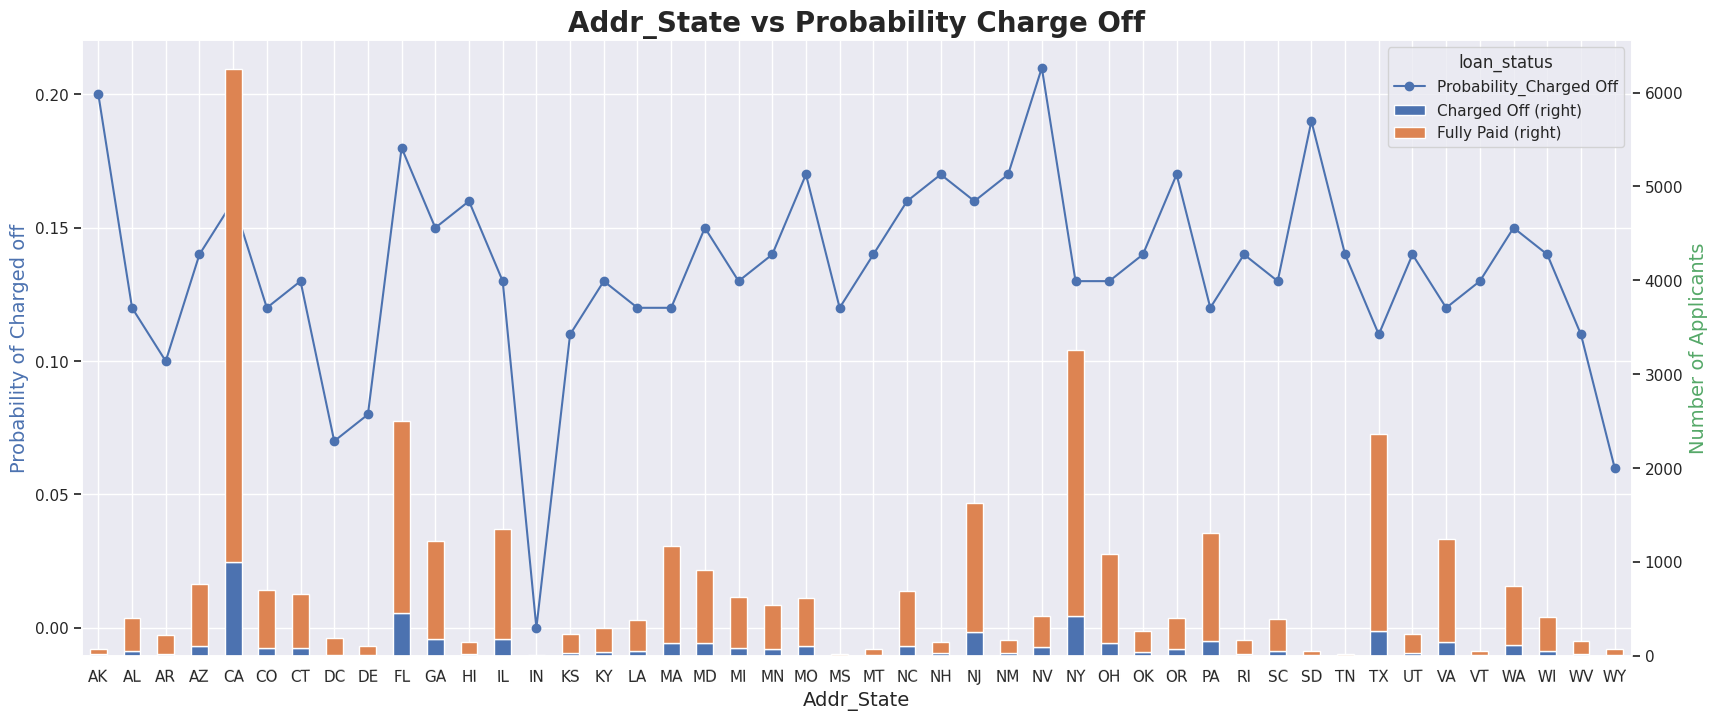

In [65]:
states = crosstab(loan_filter_states,'addr_state')
display(states)

bivariateProbability(loan_filter_states,'addr_state')

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is in <b>NV State.</b></font>

#### 6.2. Purpose of Loan vs Probability Charge Off

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
purpose,,,,,,,,,,,
car,159,15,0,13,49,1371,0,0,0,1607,0.10
credit_card,539,58,1,66,263,4487,0,0,2,5416,0.11
debt_consolidation,2765,282,0,284,787,15433,13,2,6,19572,0.15
educational,56,0,0,31,64,265,0,0,0,416,0.17
home_improvement,341,32,0,69,136,2526,1,1,2,3108,0.12
house,58,9,0,10,32,304,1,0,0,414,0.16
major_purchase,220,4,0,23,97,1937,0,0,0,2281,0.10
medical,106,5,0,20,33,574,0,0,0,738,0.16
moving,90,1,0,15,29,485,0,0,0,620,0.16


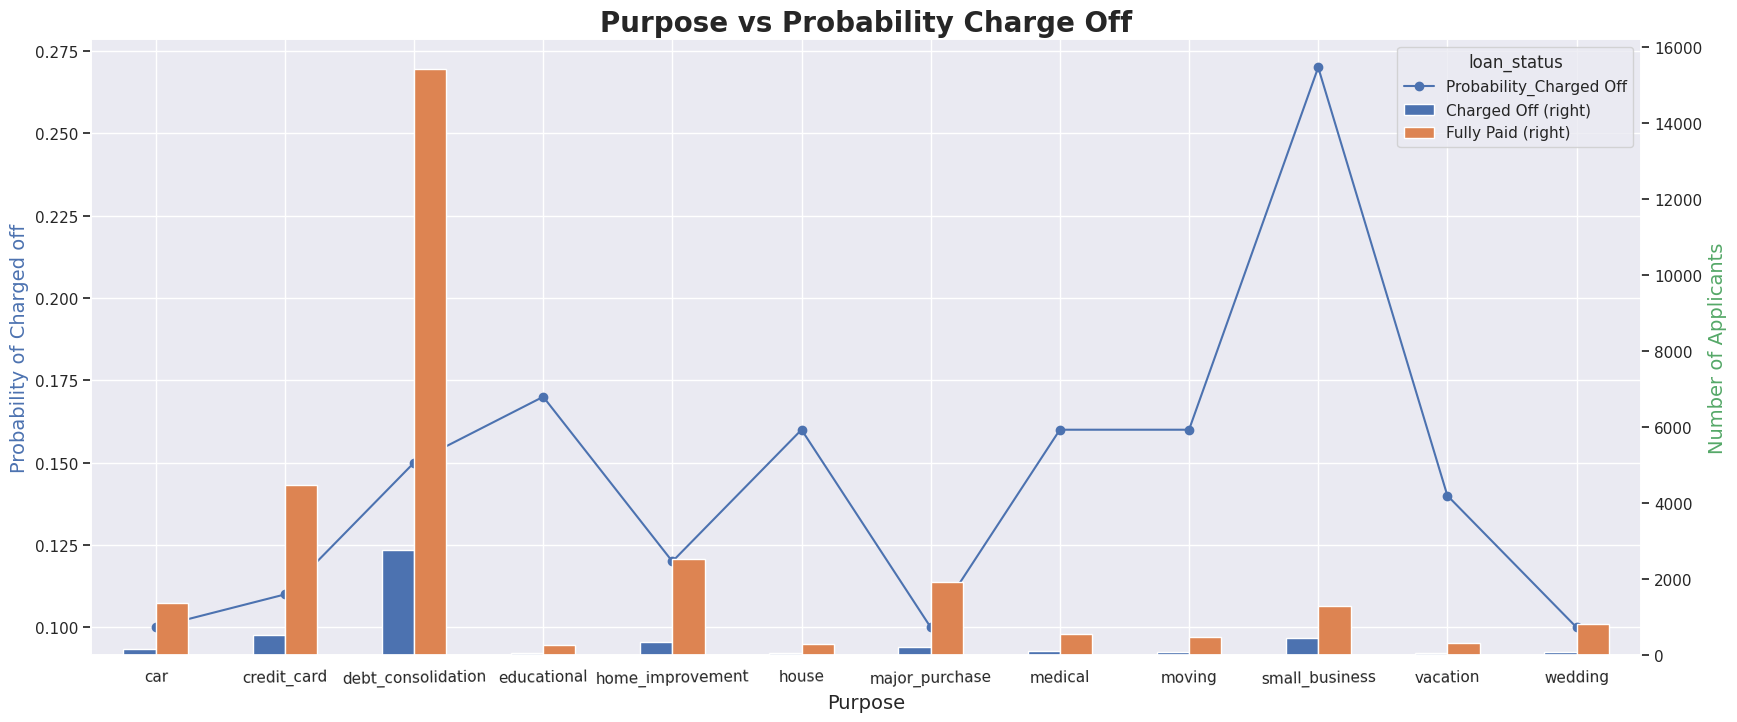

In [66]:
purpose = crosstab(loan,'purpose')
display(purpose)

bivariateProbability(loan,'purpose',False)

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is for purpose: <b>Small Business - To be considered in Charge Off prediction</b></font>

#### 6.3. Grade/Subgrade vs Probability Charge Off

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
grade,,,,,,,,,,,
A,511,16,0,7,59,8361,0,1,0,8955,0.06
B,1246,127,0,67,203,9292,1,2,3,10941,0.12
C,1172,114,0,121,387,5869,2,0,2,7667,0.17
D,993,94,0,154,420,3653,2,1,1,5318,0.21
E,646,61,1,129,321,1853,8,0,3,3022,0.26
F,293,30,0,80,134,619,1,0,2,1159,0.32
G,89,6,0,57,103,189,1,0,0,445,0.32
All,4950,448,1,615,1627,29836,15,4,11,37507,0.14


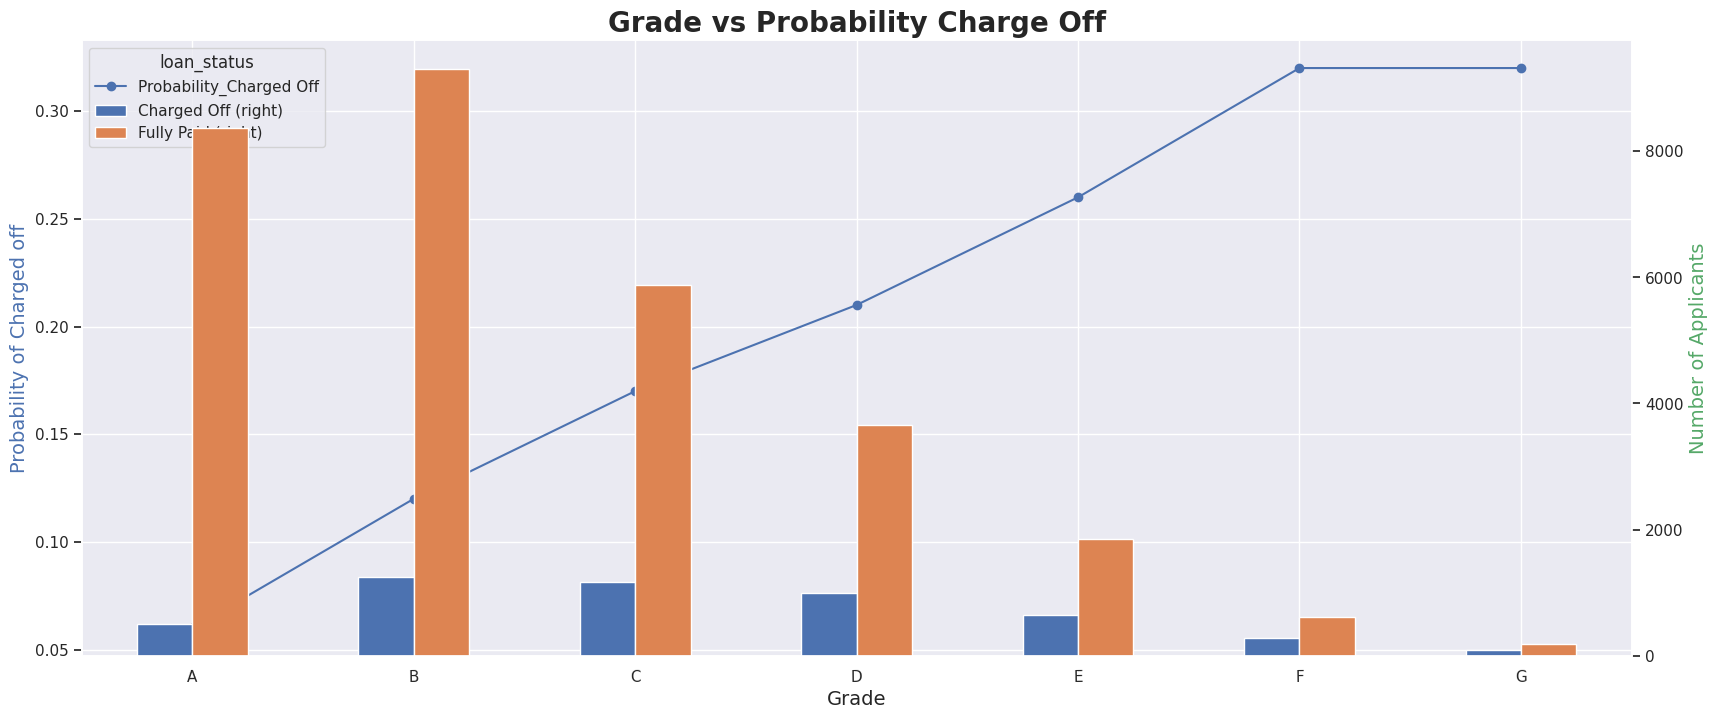

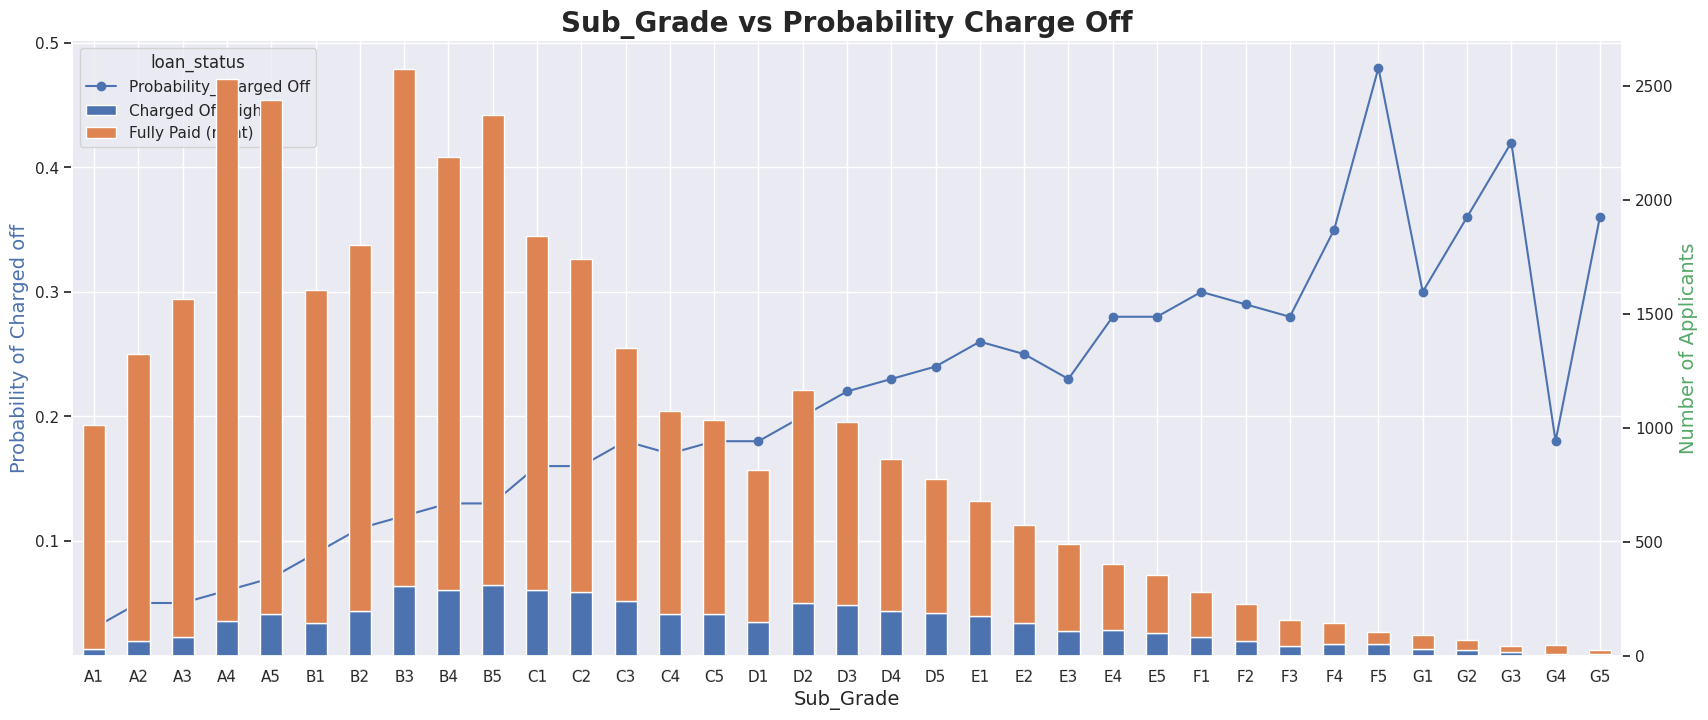

In [67]:
grade = crosstab(loan,'grade')
display(grade)

bivariateProbability(loan, 'grade', False)
bivariateProbability(loan, 'sub_grade')

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is for Grade: <b>G - To be considered in Charge Off prediction</b>, With reduction in Grade, probability of charge-off increases</font>

#### 6.4. Annual Income Range vs Probability Charge Off

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
annual_inc_range,,,,,,,,,,,
0-25000,386,6,0,62,169,1719,0,0,0,2342,0.18
25000-50000,1873,131,0,217,522,9688,5,2,2,12440,0.16
50000-75000,1527,142,1,175,424,9221,7,1,2,11500,0.14
75000-100000,674,89,0,85,277,4926,1,0,3,6055,0.12
100000 and above,490,80,0,76,235,4282,2,1,4,5170,0.10
All,4950,448,1,615,1627,29836,15,4,11,37507,0.14


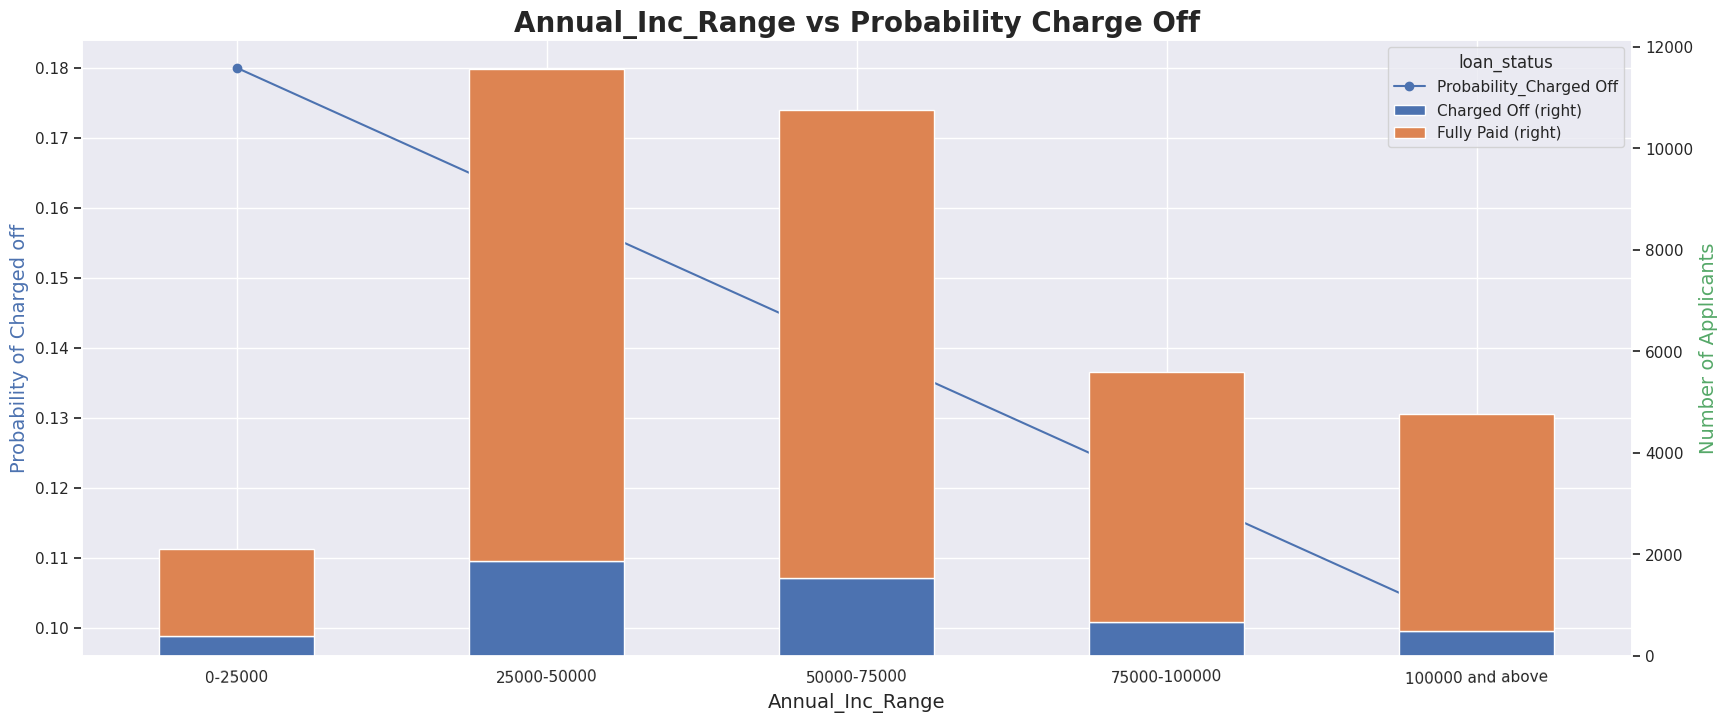

In [68]:
annual_inc_range = crosstab(loan,'annual_inc_range')
display(annual_inc_range)

bivariateProbability(loan,'annual_inc_range')

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is for <b>Lower Income Group - To be considered in Charge Off prediction</b>. With increase in Annual Income, probability of charge off reduces</font>

#### 6.5. Interest rate Range vs Probability Charge Off

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
int_rate_range,,,,,,,,,,,
0-7.5,224,0,0,2,12,4572,0,0,0,4810,0.05
7.5-10,478,30,0,25,101,5660,0,2,0,6296,0.08
10-12.5,1089,87,0,100,268,7362,0,1,3,8910,0.13
12.5-15,1291,117,0,219,664,6662,3,0,0,8956,0.16
15 and above,1599,169,1,252,551,5114,10,1,6,7703,0.24
All,4681,403,1,598,1596,29370,13,4,9,36675,0.14


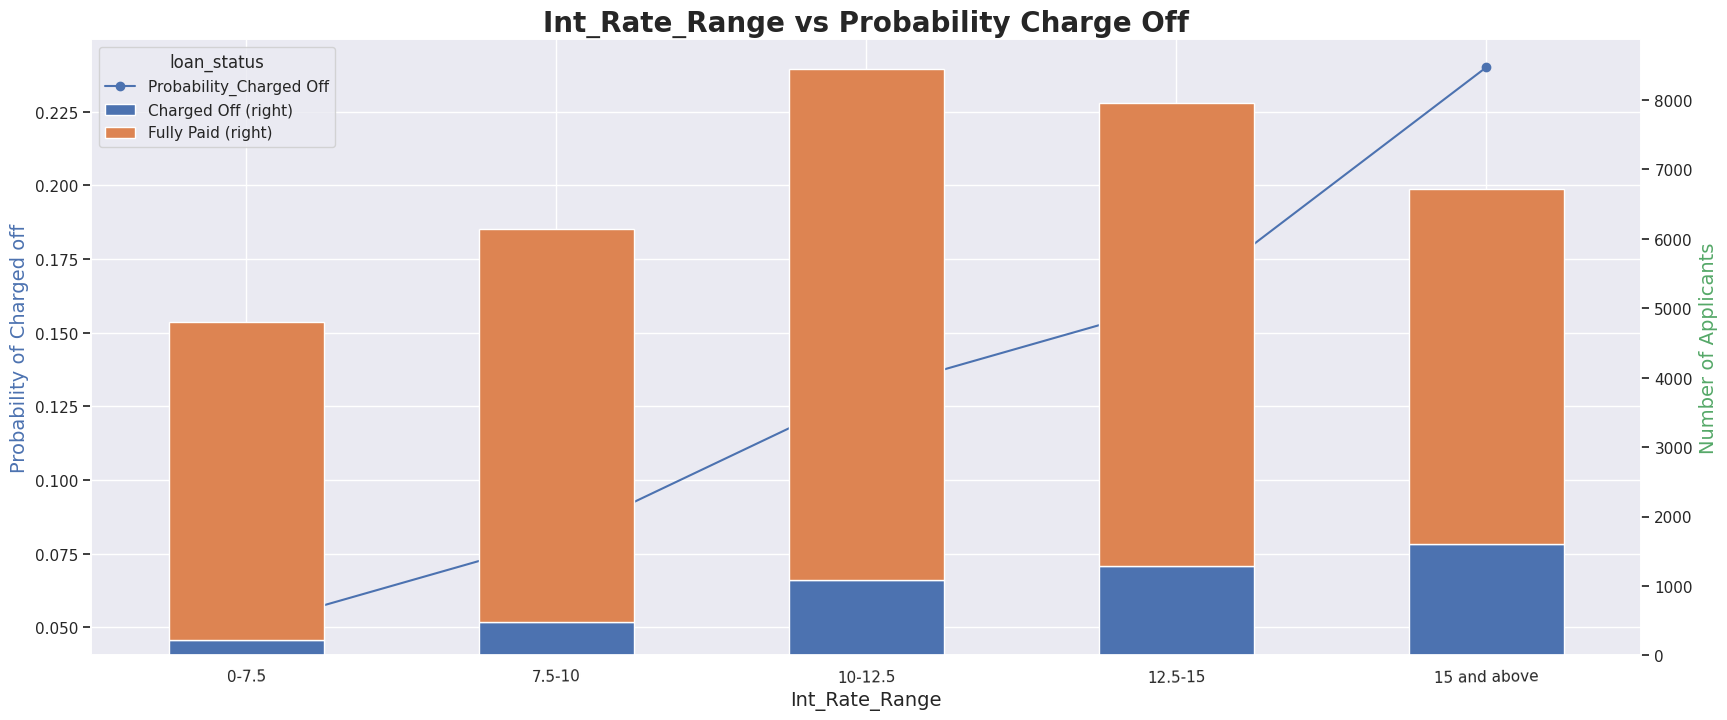

In [69]:
int_rate_range = crosstab(loan,'int_rate_range')
display(int_rate_range)

bivariateProbability(loan,'int_rate_range')

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is for <b> High interest rate (at 15% and above probability is 24%)To be considered in Charge Off prediction</b>. With increase in interest rate, probability of charge off increases</font>

#### 6.6. Employment Length vs Probability Charge Off

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days),All,Probability_Charged Off
emp_length,,,,,,,,,,,
0,191,16,0,14,15,696,0,1,0,933,0.22
< 1 year,561,24,0,89,292,3429,3,0,0,4398,0.14
1 year,396,26,1,73,215,2414,0,0,1,3126,0.14
2 years,484,37,0,71,210,3362,0,1,2,4167,0.13
3 years,485,35,0,57,166,3134,1,1,0,3879,0.13
4 years,405,40,0,50,121,2633,3,1,1,3254,0.13
5 years,413,29,0,42,106,2502,0,0,0,3092,0.14
6 years,277,25,0,33,80,1710,1,0,0,2126,0.14
7 years,232,26,0,25,55,1322,1,0,0,1661,0.15


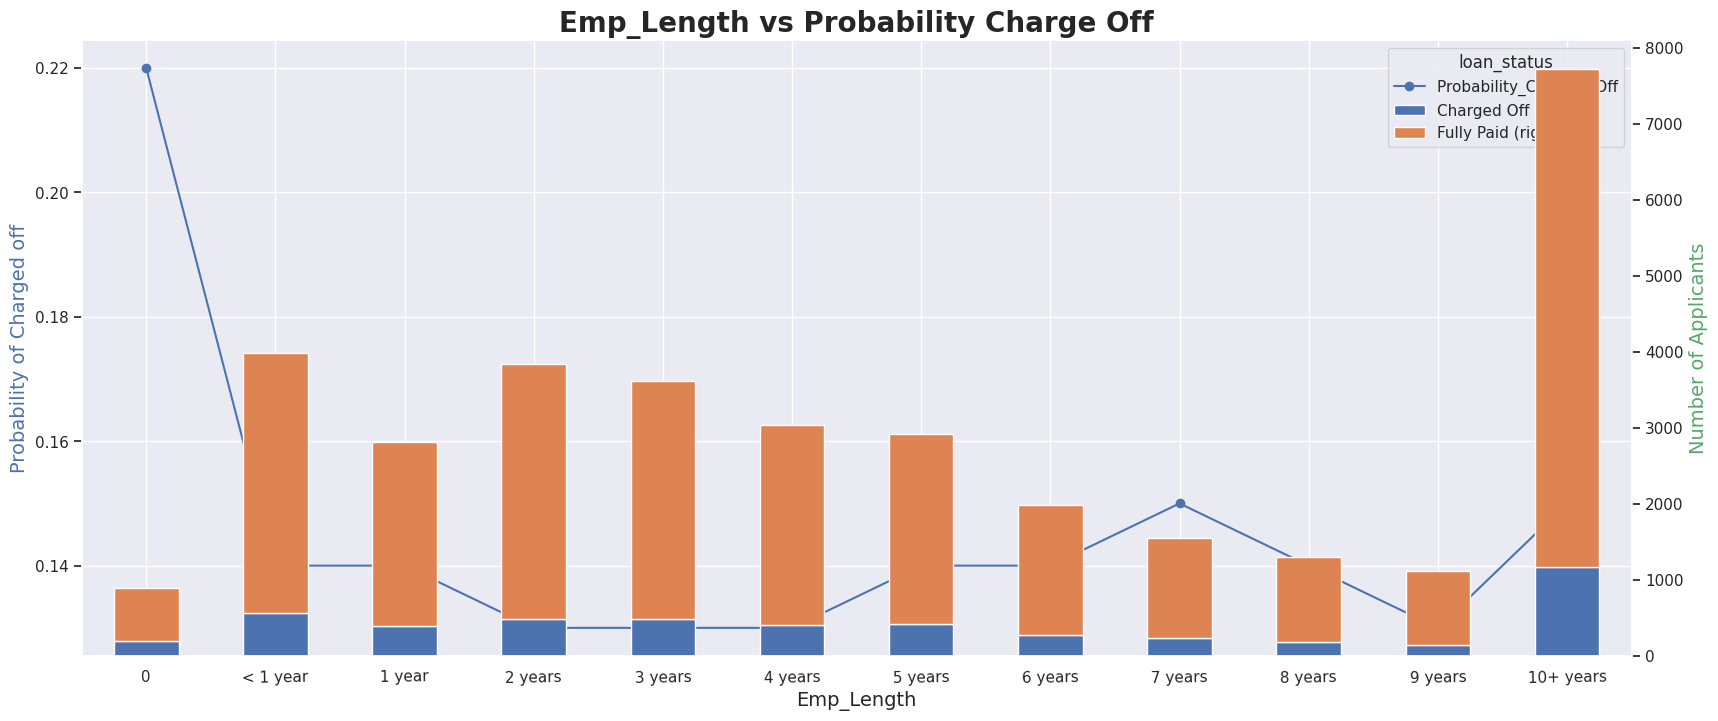

In [70]:
emp_length = crosstab(loan,'emp_length')
display(emp_length)

bivariateProbability(loan,'emp_length')

<font color='#0dab7f'><b>Intution</b>: Highest Probability of Charged Off is for : <b>Self Employed - To be considered in Charge Off prediction</b></font>

## Step 7: Inference

#### Target Variable
* <font color='blue'><b>Loan Status - Charged Off</b></font>

#### Target Variable is dependent on
1. <font color='blue'><b>Purpose of Loan - Small Business</b></font>
2. <font color='blue'><b>Grade - Grade G</b></font>
3. <font color='blue'><b>Income Level - Low Income Group</b></font>
4. <font color='blue'><b>Interest Rate - High interest rates</b></font>
5. <font color='blue'><b>Experience Level - Self Employed</b></font>